In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ETS-style exponential smoothing akin to Excel's FORECAST.ETS
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

print("Imports ready.")


Imports ready.


Load Dataset

In [ ]:
# Point to your dataset that has at least: date, category, subcategory, sales
csv_path = "/content/Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.csv"  # change to your actual path
print("Using CSV path:", csv_path)

Using CSV path: /content/Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.csv


Chcek columsn & rows

In [ ]:
preview = pd.read_csv(csv_path)
print("Rows (preview):", len(preview))
print("Columns:", list(preview.columns))
preview.head()

Rows (preview): 50004
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Purchase Price', 'Sales', 'Quantity', 'Discount', 'Profit', 'COGS', 'Country of Origin', 'Tariff %', 'Tariff', 'Transportation_Cost', 'Inventory_Cost', 'G&A_Expenses', 'FX_Gain_Loss']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Discount,Profit,COGS,Country of Origin,Tariff %,Tariff,Transportation_Cost,Inventory_Cost,G&A_Expenses,FX_Gain_Loss
0,10002,US-2017-9995,42965,42967,First Class,CG-99995,Consumer,United States,San Diego,California,...,0.0,-203.082887,1248.808567,Venezuela,0.15,162.888074,114.86000,108.59000,206.7500,-821.275180
1,5936,US-2017-169551,42923,42925,First Class,RL-19615,Consumer,United States,Philadelphia,Pennsylvania,...,0.5,3.098371,60.887498,Vietnam,0.12,6.523661,6.97680,13.25592,4.3605,1.369089
2,5937,US-2017-169551,42923,42925,First Class,RL-19615,Consumer,United States,Philadelphia,Pennsylvania,...,0.2,4.828224,7.691136,USA,0.00,0.000000,1.24416,1.01088,0.7776,0.000000
3,5938,US-2017-169551,42923,42925,First Class,RL-19615,Consumer,United States,Philadelphia,Pennsylvania,...,0.4,81.005589,429.639280,China,0.15,56.039906,54.71904,79.79860,34.1994,-4.626091
4,5939,US-2017-169551,42923,42925,First Class,RL-19615,Consumer,United States,Philadelphia,Pennsylvania,...,0.2,4.104514,6.172929,Mexico,0.05,0.293949,1.07136,1.23876,0.6696,-0.134837


Check for missing values and duplicates

In [ ]:
# ============================================
# Step 2: Check data quality (missing values & duplicates)
#========================== ==================

# Load the full dataset
df_raw = pd.read_csv(csv_path)

# Quick preview
print("Preview of raw data:")
print(df_raw.head(5))

# Basic info about columns and types
print("\n--- Dataset Info ---")
df_raw.info()

# Count missing values in each column
print("\n--- Missing values by column ---")
print(df_raw.isna().sum())

# Count duplicate rows (entire-row duplicates)
dup_count = df_raw.duplicated().sum()
print(f"\nDuplicate rows found: {dup_count}")

# If you want to drop exact duplicates (usually safe)
if dup_count > 0:
    df_raw = df_raw.drop_duplicates()
    print(f"Removed {dup_count} duplicate rows.")

print(f"\nFinal shape after cleaning duplicates: {df_raw.shape}")

Preview of raw data:
   Row ID        Order ID  Order Date  Ship Date    Ship Mode Customer ID  \
0   10002    US-2017-9995       42965      42967  First Class    CG-99995   
1    5936  US-2017-169551       42923      42925  First Class    RL-19615   
2    5937  US-2017-169551       42923      42925  First Class    RL-19615   
3    5938  US-2017-169551       42923      42925  First Class    RL-19615   
4    5939  US-2017-169551       42923      42925  First Class    RL-19615   

    Segment        Country          City         State  ...  Discount  \
0  Consumer  United States     San Diego    California  ...       0.0   
1  Consumer  United States  Philadelphia  Pennsylvania  ...       0.5   
2  Consumer  United States  Philadelphia  Pennsylvania  ...       0.2   
3  Consumer  United States  Philadelphia  Pennsylvania  ...       0.4   
4  Consumer  United States  Philadelphia  Pennsylvania  ...       0.2   

       Profit         COGS Country of Origin Tariff %      Tariff  \
0 -203.0

Handling missing values

In [ ]:
# ============================================
# Handle missing values and prepare model-ready view
# ============================================

df = df_raw.copy()

# 1) Dates: convert to datetime (robust to Excel serials)
for c in ["Order Date", "Ship Date"]:
    if c in df.columns:
        if pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_float_dtype(df[c]):
            # Excel serial -> datetime (origin 1899-12-30)
            ser = pd.to_numeric(df[c], errors="coerce")
            df[c] = pd.to_datetime(ser, unit="D", origin="1899-12-30", errors="coerce")
        else:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# 2) Sales: impute missing by Sub-Category median (fallback to global median)
if {"Sales", "Sub-Category"}.issubset(df.columns):
    miss_mask = df["Sales"].isna()
    if miss_mask.any():
        sub_med = df.groupby("Sub-Category")["Sales"].median()
        df.loc[miss_mask, "Sales"] = df.loc[miss_mask, "Sub-Category"].map(sub_med)
        # global fallback if any remain
        if df["Sales"].isna().any():
            df["Sales"] = df["Sales"].fillna(df["Sales"].median())

# 3) Ship Mode: infer for missing using (Ship Date - Order Date), if both dates exist
if "Ship Mode" in df.columns and df["Ship Mode"].isna().any():
    mask = df["Ship Mode"].isna()
    if {"Ship Date", "Order Date"}.issubset(df.columns):
        day_diff = (df.loc[mask, "Ship Date"] - df.loc[mask, "Order Date"]).dt.days

        def infer_mode(days):
            if pd.isna(days):
                return np.nan
            if days == 0:
                return "Same Day"
            elif days <= 3:
                return "First Class"
            elif days <= 6:
                return "Second Class"
            else:
                return "Standard Class"

        df.loc[mask, "Ship Mode"] = day_diff.apply(infer_mode)

# 4) Tidy categorical text and clip Discount
if "Ship Mode" in df.columns:
    canon = {
        "Same Day": "Same Day",
        "First Class": "First Class",
        "Second Class": "Second Class",
        "Standard Class": "Standard Class",
    }
    df["Ship Mode"] = (
        df["Ship Mode"].astype("string").str.strip().str.title().map(canon).fillna(df["Ship Mode"])
    )

if "Discount" in df.columns:
    df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce").clip(0, 1)

# 5) General safety fills
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if num_cols:
    # Do not overwrite Sales again; it is already handled
    fill_nums = [c for c in num_cols if c != "Sales"]
    if fill_nums:
        df[fill_nums] = df[fill_nums].apply(lambda s: s.fillna(s.median()))

for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

# 6) Sanity checks
if "Sales" in df.columns:
    # No negative sales: set to median sales if any negatives exist
    neg_sales = (pd.to_numeric(df["Sales"], errors="coerce") < 0).sum()
    if neg_sales:
        df.loc[df["Sales"] < 0, "Sales"] = df["Sales"].median()

# 7) Report remaining missing
print("\nAfter handling missing values:")
post_missing = df.isna().sum()
print(post_missing[post_missing > 0] if (post_missing > 0).any() else "No remaining missing values.")

# Keep a full cleaned copy
df_cleaned = df.copy()

# 8) Model-ready view: narrow to the four required columns with canonical names
df = df_cleaned[["Order Date", "Category", "Sub-Category", "Sales"]].copy()
df = df.rename(columns={
    "Order Date": "date",
    "Category": "category",
    "Sub-Category": "subcategory",
    "Sales": "sales"
})

# Ensure types and drop rows missing key fields
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df = df.dropna(subset=["date", "subcategory", "sales"]).sort_values("date").reset_index(drop=True)

print("\nModel-ready sample (date, category, subcategory, sales):")
print(df.head(5))
print(df.tail(5))
print("Shape:", df.shape)



After handling missing values:
No remaining missing values.

Model-ready sample (date, category, subcategory, sales):
        date         category  subcategory     sales
0 2014-01-03        Furniture       Tables   393.165
1 2014-01-03       Technology  Accessories    41.900
2 2014-01-03  Office Supplies     Supplies     7.360
3 2014-01-03  Office Supplies      Binders  1793.980
4 2014-01-03  Office Supplies        Paper    16.448
            date         category subcategory    sales
49999 2017-12-30  Office Supplies       Paper   92.940
50000 2017-12-30       Technology      Phones  191.980
50001 2017-12-30  Office Supplies  Appliances  209.300
50002 2017-12-30  Office Supplies   Fasteners    3.024
50003 2017-12-30  Office Supplies   Fasteners   21.480
Shape: (50004, 4)


Handling duplicates

In [ ]:
# ============================================
# Deduplicate by business key and rebuild model-ready df
# ============================================

# Work from the cleaned frame if it exists, else from raw
base = df_cleaned.copy() if "df_cleaned" in globals() else df_raw.copy()

# Ensure the business key exists
bk = ["Order ID", "Product ID", "Order Date"]
missing_bk = [c for c in bk if c not in base.columns]
assert not missing_bk, f"Missing columns needed for duplicate handling: {missing_bk}"

# Make sure Order Date is datetime (safe even if already converted)
base["Order Date"] = pd.to_datetime(base["Order Date"], errors="coerce")

before = len(base)

# 1) Find candidate duplicates by the business key
dup_mask = base.duplicated(subset=bk, keep=False)
dups = base.loc[dup_mask].sort_values(bk)

n_groups = dups[bk].drop_duplicates().shape[0]
print(f"Candidate duplicate rows (by {bk}): {dups.shape[0]} across {n_groups} key groups")

# 2) Check if duplicates are truly identical or if non-key fields conflict
nonkey_cols = [c for c in base.columns if c not in bk]
# For each duplicate group, see if any non-key column has >1 unique value
conflict_flags = (
    dups.groupby(bk)[nonkey_cols]
        .nunique(dropna=False)
        .max(axis=1)            # max # unique values across all non-key cols
        .gt(1)                  # True if any non-key col differs within the group
)
has_conflicts = conflict_flags.any()
print(f"Conflicting duplicate key groups (non-key fields differ): {int(conflict_flags.sum())}")

# 3) Resolve duplicates
if not has_conflicts:
    # Simple case: duplicates are exact copies → keep first
    df_nodup_full = base.drop_duplicates(subset=bk, keep="first").reset_index(drop=True)
else:
    # Robust case: aggregate to avoid double counting
    # Sum numeric columns (except IDs etc.); take 'first' for non-numerics
    num_cols = base.select_dtypes(include=[np.number]).columns.tolist()
    do_not_sum = {"Row ID", "Postal Code"}  # numeric identifiers to exclude from summing
    num_cols = [c for c in num_cols if c not in do_not_sum and c not in bk]

    agg_spec = {c: "sum" for c in num_cols}
    for c in base.columns:
        if c not in bk and c not in agg_spec:
            agg_spec[c] = "first"

    df_nodup_full = (
        base.groupby(bk, dropna=False)
            .agg(agg_spec)
            .reset_index()
    )

removed = before - len(df_nodup_full)
print(f"Duplicates removed: {removed}")

# Keep a cleaned, deduplicated full copy
df_cleaned = df_nodup_full.copy()

# --------------------------------------------
# Rebuild the model-ready view for forecasting
# (date, category, subcategory, sales)
# --------------------------------------------
df = df_cleaned[["Order Date", "Category", "Sub-Category", "Sales"]].copy()
df = df.rename(columns={
    "Order Date": "date",
    "Category": "category",
    "Sub-Category": "subcategory",
    "Sales": "sales"
})

# Enforce types and drop any rows missing key fields
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df = df.dropna(subset=["date", "subcategory", "sales"]).sort_values("date").reset_index(drop=True)

print("\nModel-ready sample after de-duplication:")
print(df.head(5))
print("Shape:", df.shape)


Candidate duplicate rows (by ['Order ID', 'Product ID', 'Order Date']): 340 across 170 key groups
Conflicting duplicate key groups (non-key fields differ): 170
Duplicates removed: 170

Model-ready sample after de-duplication:
        date         category subcategory    sales
0 2014-01-03  Office Supplies       Paper   16.448
1 2014-01-03        Furniture      Tables  393.165
2 2014-01-03  Office Supplies     Binders   13.392
3 2014-01-03  Office Supplies    Supplies    7.360
4 2014-01-03  Office Supplies       Paper   21.400
Shape: (49834, 4)


Narrow the dataset to timestamp and desired variable to predict / Interpolation if necessary

In [ ]:
# Keep only the columns needed and standardize names
df = pd.read_csv(csv_path)

# Map to expected names for THIS dataset (Superstore-style)
COLUMN_MAP = {
    "date": "Order Date",
    "category": "Category",
    "subcategory": "Sub-Category",
    "sales": "Sales",
    "profit": "Profit"
}

# Rename to canonical lowercase names used downstream
df = df.rename(columns={
    COLUMN_MAP["date"]: "date",
    COLUMN_MAP["category"]: "category",
    COLUMN_MAP["subcategory"]: "subcategory",
    COLUMN_MAP["sales"]: "sales",
    COLUMN_MAP["profit"]: "profit"
})

# Coerce date: handle both Excel serial (e.g., 42682) and normal strings
if np.issubdtype(df["date"].dtype, np.number):
    # Excel serial dates use origin 1899-12-30
    df["date"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["date"].round().astype("Int64"), unit="D")
else:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure numeric sales and profit
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")

# Drop rows with missing key fields
df = df.dropna(subset=["date", "subcategory", "sales", "profit"])

# Basic sanity: set negative sales or profit to zero (defensible for this assignment)
neg_sales = (df["sales"] < 0).sum()
neg_profit = (df["profit"] < 0).sum()

if neg_sales > 0:
    print(f"Warning: {neg_sales} negative sales found. Setting to zero for analysis.")
    df.loc[df["sales"] < 0, "sales"] = 0.0
if neg_profit > 0:
    print(f"Warning: {neg_profit} negative profits found. Setting to zero for analysis.")
    df.loc[df["profit"] < 0, "profit"] = 0.0

# Sort and keep only required columns
df = df[["date", "category", "subcategory", "sales", "profit"]].sort_values("date").reset_index(drop=True)

# 4) Zero-fill diagnostics
zero_sales = (df["sales"] == 0).sum()
zero_profit = (df["profit"] == 0).sum()
total_rows = len(df)

print(f"\nZero-sale months: {zero_sales:,} out of {total_rows:,} total "
      f"({zero_sales / total_rows:.2%} of all records)")
print(f"Zero-profit months: {zero_profit:,} out of {total_rows:,} total "
      f"({zero_profit / total_rows:.2%} of all records)")

zero_by_sub = (
    df.groupby("subcategory")[["sales", "profit"]]
    .apply(lambda s: pd.Series({
        "zero_sales": (s["sales"] == 0).sum(),
        "zero_profit": (s["profit"] == 0).sum()
    }))
    .reset_index()
    .sort_values("zero_sales", ascending=False)
)

print("\nSubcategories with most zero-sale or zero-profit months:")
print(zero_by_sub.head(10))

print("\nCleaned sample:")
df.head()


Zero-sale months: 0 out of 50,002 total (0.00% of all records)
Zero-profit months: 421 out of 50,002 total (0.84% of all records)

Subcategories with most zero-sale or zero-profit months:
   subcategory  zero_sales  zero_profit
0  Accessories           0           14
1   Appliances           0           96
2          Art           0           25
3      Binders           0          124
4    Bookcases           0           18
5       Chairs           0            0
6      Copiers           0            0
7    Envelopes           0            3
8    Fasteners           0           11
9  Furnishings           0           90

Cleaned sample:


,date,category,subcategory,sales,profit
0,2014-01-03,Office Supplies,Binders,13.392,3.902005
1,2014-01-03,Office Supplies,Supplies,7.360,1.848766
2,2014-01-03,Technology,Accessories,41.900,12.204665
3,2014-01-03,Office Supplies,Paper,16.448,3.640761
4,2014-01-03,Office Supplies,Paper,21.400,7.199378


convert daily to monthly and aggregate by subcategory

In [ ]:
# For this assignment, enforce monthly frequency and aggregate sales & profit by subcategory

# make sure 'date' is datetime and numeric cols are numeric
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df.get("profit"), errors="coerce")  # handles if 'profit' exists
df = df.dropna(subset=["date", "subcategory", "sales", "profit"])

# create a month-start timestamp
df["year_month"] = df["date"].dt.to_period("M").dt.to_timestamp()

# aggregate to monthly sales & profit per subcategory
monthly = (
    df.groupby(["subcategory", "year_month"], as_index=False)[["sales", "profit"]]
      .sum()
      .rename(columns={"year_month": "timestamp"})
      .sort_values(["subcategory", "timestamp"])
      .reset_index(drop=True)
)

# optional: ensure every subcategory has a continuous monthly index
# missing months will be filled with 0 for both sales and profit
all_months = pd.date_range(monthly["timestamp"].min(), monthly["timestamp"].max(), freq="MS")
filled = []
for sub in monthly["subcategory"].unique():
    tmp = monthly.loc[monthly["subcategory"] == sub, ["timestamp", "sales", "profit"]].set_index("timestamp")
    tmp = tmp.reindex(all_months, fill_value=0.0)
    tmp = tmp.rename_axis("timestamp").reset_index()
    tmp["subcategory"] = sub
    filled.append(tmp)

data_m = (
    pd.concat(filled, ignore_index=True)[["subcategory", "timestamp", "sales", "profit"]]
      .sort_values(["subcategory", "timestamp"])
      .reset_index(drop=True)
)

print("Monthly sample:")
print(data_m.head(10))
print("\nShape:", data_m.shape)
print("Unique subcategories:", data_m["subcategory"].nunique())

# ---- Zero-fill diagnostics ----
zero_sales_count = (data_m["sales"] == 0).sum()
zero_profit_count = (data_m["profit"] == 0).sum()
total_rows = len(data_m)

print(f"\nZero-sale months: {zero_sales_count:,} out of {total_rows:,} total "
      f"({zero_sales_count / total_rows:.2%})")
print(f"Zero-profit months: {zero_profit_count:,} out of {total_rows:,} total "
      f"({zero_profit_count / total_rows:.2%})")

zero_by_sub = (
    data_m.groupby("subcategory")
          .agg(
              zero_sales=("sales", lambda s: (s == 0).sum()),
              zero_profit=("profit", lambda s: (s == 0).sum())
          )
          .reset_index()
          .sort_values(["zero_sales", "zero_profit"], ascending=False)
)
print("\nSubcategories with most zero months (sales/profit):")
print(zero_by_sub.head(10))


# optional: zero share per subcategory (both metrics)
zero_share_by_sub = (
    data_m.assign(is_zero_sales=data_m["sales"] == 0,
                  is_zero_profit=data_m["profit"] == 0)
          .groupby("subcategory")
          .agg(
              zero_sales_months=("is_zero_sales", "sum"),
              zero_profit_months=("is_zero_profit", "sum"),
              total_months=("is_zero_sales", "size")
          )
          .assign(
              zero_sales_share=lambda d: d["zero_sales_months"] / d["total_months"],
              zero_profit_share=lambda d: d["zero_profit_months"] / d["total_months"]
          )
          .sort_values(["zero_sales_share", "zero_profit_share"], ascending=False)
          .reset_index()
)
print("\nSubcategories by zero-month share (sales/profit):")
print(zero_share_by_sub.head(10))


Monthly sample:
   subcategory  timestamp      sales       profit
0  Accessories 2014-01-01  12451.996  3465.674506
1  Accessories 2014-02-01   2914.812   866.603550
2  Accessories 2014-03-01  12459.782  3313.223403
3  Accessories 2014-04-01  12062.796  3312.774747
4  Accessories 2014-05-01  12999.688  3513.273562
5  Accessories 2014-06-01   9674.224  2597.630857
6  Accessories 2014-07-01  11657.552  2779.836751
7  Accessories 2014-08-01  11704.982  3194.520459
8  Accessories 2014-09-01  20896.316  5851.118841
9  Accessories 2014-10-01  11008.874  2953.510145

Shape: (816, 4)
Unique subcategories: 17

Zero-sale months: 2 out of 816 total (0.25%)
Zero-profit months: 2 out of 816 total (0.25%)

Subcategories with most zero months (sales/profit):
   subcategory  zero_sales  zero_profit
6      Copiers           2            2
0  Accessories           0            0
1   Appliances           0            0
2          Art           0            0
3      Binders           0            0
4    B

winsorization (optionl)

In [ ]:
# ============================================
# Step 7: Winsorization (cap outliers per subcategory)
# ============================================

def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    """Clip a series between the 1st and 99th percentile by default."""
    lo, hi = s.quantile(lower_q), s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

# Apply winsorization separately for each subcategory
data_m["sales_w"] = (
    data_m.groupby("subcategory", group_keys=False)["sales"]
          .apply(lambda s: winsorize_series(s, 0.01, 0.99))
)

data_m["profit_w"] = (
    data_m.groupby("subcategory", group_keys=False)["profit"]
          .apply(lambda s: winsorize_series(s, 0.01, 0.99))
)

# Identify which values changed
sales_changed_mask = data_m["sales_w"].ne(data_m["sales"]) & data_m["sales"].notna()
profit_changed_mask = data_m["profit_w"].ne(data_m["profit"]) & data_m["profit"].notna()

sales_changed_rows = data_m.loc[sales_changed_mask, ["subcategory", "timestamp", "sales", "sales_w"]]
profit_changed_rows = data_m.loc[profit_changed_mask, ["subcategory", "timestamp", "profit", "profit_w"]]

num_sales_changed = int(sales_changed_mask.sum())
num_profit_changed = int(profit_changed_mask.sum())

print(f"\nWinsorization complete.")
print(f"Sales clipped: {num_sales_changed:,} values.")
print(f"Profit clipped: {num_profit_changed:,} values.")

if num_sales_changed > 0:
    print("\nRows with changed sales:")
    print(sales_changed_rows.head(10))
else:
    print("No sales values were clipped.")

if num_profit_changed > 0:
    print("\nRows with changed profit:")
    print(profit_changed_rows.head(10))
else:
    print("No profit values were clipped.")

# Choose which column to model later
TARGET_COL_SALES = "sales_w"
TARGET_COL_PROFIT = "profit_w"



Winsorization complete.
Sales clipped: 33 values.
Profit clipped: 33 values.

Rows with changed sales:
     subcategory  timestamp       sales       sales_w
1    Accessories 2014-02-01   2914.8120   3604.297300
44   Accessories 2017-09-01  39105.4100  38958.566960
49    Appliances 2014-02-01    737.9580   1121.541920
95    Appliances 2017-12-01  26952.0460  26522.212200
97           Art 2014-02-01    444.6240    546.808580
142          Art 2017-11-01   6008.3780   5891.880040
156      Binders 2015-01-01   3024.5930   3563.756320
188      Binders 2017-09-01  54945.7640  54891.919390
193    Bookcases 2014-02-01   2649.0352   2824.668936
239    Bookcases 2017-12-01  24951.4282  24456.818859

Rows with changed profit:
     subcategory  timestamp        profit      profit_w
1    Accessories 2014-02-01    866.603550   1044.826412
44   Accessories 2017-09-01  10695.162112  10297.420814
49    Appliances 2014-02-01    249.832193    359.714724
94    Appliances 2017-11-01   8431.808117   8247.93

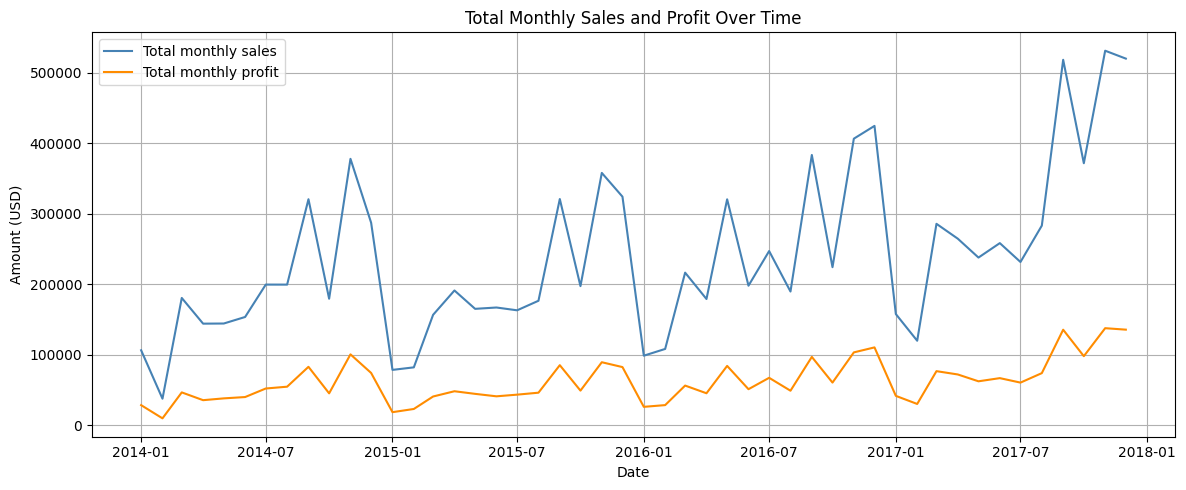

In [ ]:
# Optional: overall monthly total sales and profit across all subcategories
overall = (
    data_m.groupby("timestamp", as_index=True)[["sales", "profit"]]
          .sum()
          .asfreq("MS")
)

plt.figure(figsize=(12,5))
plt.plot(overall.index, overall["sales"], label="Total monthly sales", color="steelblue")
plt.plot(overall.index, overall["profit"], label="Total monthly profit", color="darkorange")
plt.title("Total Monthly Sales and Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Amount (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Profitability filter

In [ ]:
# Identify the five most profitable subcategories over the historical period
if "profit" in data_m.columns and data_m["profit"].notna().any():
    # Use total profit as the metric
    totals = (
        data_m.groupby("subcategory", as_index=False)["profit"]
              .sum()
              .sort_values("profit", ascending=False)
    )
    metric_used = "profit"
else:
    # Fallback: use sales as a proxy for profitability
    totals = (
        data_m.groupby("subcategory", as_index=False)["sales"]
              .sum()
              .sort_values("sales", ascending=False)
    )
    metric_used = "sales (proxy for profit)"
    print("Note: Profit data unavailable. Using total sales as a proxy for profitability.")

top5 = totals.head(5)["subcategory"].tolist()

print(f"Top 5 subcategories by total {metric_used}:")
print(top5)
totals.head()

Top 5 subcategories by total profit:
['Phones', 'Chairs', 'Storage', 'Binders', 'Machines']


,subcategory,profit
13,Phones,427270.437600
5,Chairs,365412.704540
14,Storage,331206.117501
3,Binders,302053.957466
11,Machines,239108.186159


step 9: applying forecasting

In [ ]:
# Model selection by metrics + future forecasts with plots
# Chooses best model per subcategory by lowest average Test RMSE, then forecasts 2018
# Assumes data_m (subcategory, timestamp, sales_w) and top5 already exist

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----------------------------
# Config
# ----------------------------
SEASONAL_PERIODS = 12
FORECAST_HORIZON = 12
LOOKBACK_M = 60
PLOT_FIGSIZE = (12, 5)

# Backtest folds within 2014–2017
FOLDS = [
    # Train up to 2015-12, Test 2016-H1
    ("2014-01-01", "2015-12-31", "2016-01-01", "2016-06-30"),
    # Train up to 2016-12, Test 2017-H1
    ("2014-01-01", "2016-12-31", "2017-01-01", "2017-06-30"),
    # Train up to 2017-06, Test 2017-H2
    ("2014-01-01", "2017-06-30", "2017-07-01", "2017-12-31"),
]

# ----------------------------
# Metrics
# ----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_metrics(y_true, y_pred, label):
    return {
        "Model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }

# ----------------------------
# Seasonal Naive
# ----------------------------
def seasonal_naive_forecast(train_series, forecast_index, seasonal_periods=12):
    if len(train_series) == 0:
        return np.full(len(forecast_index), np.nan)
    vals = []
    for ts in forecast_index:
        src = ts - pd.DateOffset(months=seasonal_periods)
        vals.append(train_series.loc[src] if src in train_series.index else train_series.iloc[-1])
    return np.array(vals)

def seasonal_naive_insample(train_series, seasonal_periods=12):
    idx = train_series.index
    fitted = []
    for t in range(len(idx)):
        src_pos = t - seasonal_periods
        fitted.append(train_series.iloc[src_pos] if src_pos >= 0 else np.nan)
    return pd.Series(fitted, index=idx)

# ----------------------------
# XGBoost (aligned with class; compatible with older xgboost)
# ----------------------------
def make_time_features(idx: pd.DatetimeIndex) -> pd.DataFrame:
    X = pd.DataFrame(index=idx)
    X["year"] = X.index.year
    X["month"] = X.index.month
    X["month_sin"] = np.sin(2*np.pi*X["month"]/12.0)
    X["month_cos"] = np.cos(2*np.pi*X["month"]/12.0)
    return X

def make_lag_features(y: pd.Series, max_lag=12, windows=(3,6,12)) -> pd.DataFrame:
    X = pd.DataFrame(index=y.index)
    for l in range(1, max_lag+1):
        X[f"lag_{l}"] = y.shift(l)
    for w in windows:
        X[f"roll_mean_{w}"] = y.shift(1).rolling(w).mean()
    return X

def _xgb_model():
    # move eval_metric into constructor; avoid eval_metric/early_stopping in fit()
    return XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        reg_alpha=1.0,
        eval_metric="rmse",
        random_state=42
    )

def xgb_fit_predict_aligned(train_series: pd.Series,
                            test_index: pd.DatetimeIndex,
                            lookback_m: int = LOOKBACK_M):
    """
    Train on recent LOOKBACK_M months using lag1..lag12, rolling means (3,6,12), and calendar features.
    Returns in-sample fitted (on supervised rows) and recursive predictions for the test_index.
    """
    train_series = train_series.asfreq("MS").astype(float).dropna()
    if len(train_series) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float), None

    y_hist = train_series.iloc[-lookback_m:] if len(train_series) > lookback_m else train_series
    X_lag = make_lag_features(y_hist, max_lag=12, windows=(3,6,12))
    X_cal = make_time_features(y_hist.index)
    X_sup = pd.concat([X_lag, X_cal], axis=1)
    XY = pd.concat([X_sup, y_hist.rename("y")], axis=1).dropna()

    if len(XY) < 12:
        return pd.Series(dtype=float), pd.Series(dtype=float), None

    X_train = XY.drop(columns=["y"])
    y_train = XY["y"]

    model = _xgb_model()
    model.fit(X_train, y_train)

    y_hat_train = pd.Series(model.predict(X_train), index=X_train.index)

    if len(test_index) == 0:
        return y_hat_train, pd.Series(dtype=float), model

    # recursive over test_index
    y_roll = y_hist.copy()
    preds = []
    for dt_i in pd.DatetimeIndex(sorted(test_index)):
        X_l_full = make_lag_features(y_roll, max_lag=12, windows=(3,6,12))
        row_lag = X_l_full.iloc[[-1]]
        row_cal = make_time_features(pd.DatetimeIndex([dt_i]))
        X_row = pd.concat([row_lag.reset_index(drop=True),
                           row_cal.reset_index(drop=True)], axis=1)
        # align columns
        missing_cols = [c for c in X_train.columns if c not in X_row.columns]
        for c in missing_cols:
            X_row[c] = 0.0
        X_row = X_row[X_train.columns]

        y_pred = float(model.predict(X_row)[0])
        preds.append((dt_i, y_pred))
        y_roll = pd.concat([y_roll, pd.Series([y_pred], index=[dt_i])])

    y_hat_test = pd.Series({dt: val for dt, val in preds}).sort_index()
    return y_hat_train, y_hat_test, model

def xgb_recursive_forecast_aligned(history_series: pd.Series,
                                   steps: int = FORECAST_HORIZON,
                                   lookback_m: int = LOOKBACK_M):
    """
    Final forward forecast using aligned features and recursive roll.
    Returns fc_mean, fc_lw95, fc_up95 with sigma from in-sample residuals.
    """
    history_series = history_series.asfreq("MS").astype(float).dropna()
    if len(history_series) == 0:
        future_idx = pd.date_range(history_series.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq="MS")
        nan = pd.Series(index=future_idx, data=np.nan)
        return nan, nan, nan

    y_hist = history_series.iloc[-lookback_m:] if len(history_series) > lookback_m else history_series
    X_lag = make_lag_features(y_hist, max_lag=12, windows=(3,6,12))
    X_cal = make_time_features(y_hist.index)
    X_sup = pd.concat([X_lag, X_cal], axis=1)
    XY = pd.concat([X_sup, y_hist.rename("y")], axis=1).dropna()

    if len(XY) < 12:
        future_idx = pd.date_range(y_hist.index.max() + pd.offsets.MonthBegin(1), periods=steps, freq="MS")
        nan = pd.Series(index=future_idx, data=np.nan)
        return nan, nan, nan

    X_train = XY.drop(columns=["y"])
    y_train = XY["y"]
    model = _xgb_model()
    model.fit(X_train, y_train)

    # residual sigma for PI
    train_pred = pd.Series(model.predict(X_train), index=X_train.index)
    resid = (y_train.loc[train_pred.index] - train_pred).dropna()
    sigma = resid.std(ddof=1) if len(resid) > 1 else 0.0
    z = 1.96

    last_date = y_hist.index.max()
    future_idx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=steps, freq="MS")
    y_roll = y_hist.copy()
    preds = []
    for dt_i in future_idx:
        X_l_full = make_lag_features(y_roll, max_lag=12, windows=(3,6,12))
        row_lag  = X_l_full.iloc[[-1]]
        row_cal  = make_time_features(pd.DatetimeIndex([dt_i]))
        X_row = pd.concat([row_lag.reset_index(drop=True), row_cal.reset_index(drop=True)], axis=1)
        missing_cols = [c for c in X_train.columns if c not in X_row.columns]
        for c in missing_cols:
            X_row[c] = 0.0
        X_row = X_row[X_train.columns]
        pred = float(model.predict(X_row)[0])
        preds.append(pred)
        y_roll = pd.concat([y_roll, pd.Series([pred], index=[dt_i])])

    fc_mean = pd.Series(preds, index=future_idx)
    fc_lw95 = fc_mean - z * sigma
    fc_up95 = fc_mean + z * sigma
    return fc_mean, fc_lw95, fc_up95

# ----------------------------
# Gaussian intervals helper
# ----------------------------
def gaussian_pi_from_residuals(forecast_series, resid, horizon, inflate=True):
    sigma = np.nanstd(resid, ddof=1)
    h = np.arange(1, horizon + 1)
    scale = np.sqrt(h) if inflate else 1.0
    z80, z95 = 1.2815515655446004, 1.959963984540054
    idx = forecast_series.index
    lw80 = forecast_series.values - z80 * sigma * scale
    up80 = forecast_series.values + z80 * sigma * scale
    lw95 = forecast_series.values - z95 * sigma * scale
    up95 = forecast_series.values + z95 * sigma * scale
    return {
        "lw80": pd.Series(lw80, index=idx),
        "up80": pd.Series(up80, index=idx),
        "lw95": pd.Series(lw95, index=idx),
        "up95": pd.Series(up95, index=idx),
    }

# ----------------------------
# Data prep
# ----------------------------
data_m = data_m.copy()
data_m["timestamp"] = pd.to_datetime(data_m["timestamp"])

# ----------------------------
# Backtests
# ----------------------------
rows = []
for sub in top5:
    s = (
        data_m.loc[data_m["subcategory"] == sub, ["timestamp", "sales_w"]]
        .set_index("timestamp")
        .asfreq("MS")
        .sort_index()["sales_w"]
    ).loc["2014-01-01":"2017-12-31"].dropna()
    if s.empty or len(s) < 24:
        continue

    for tr_start, tr_end, te_start, te_end in FOLDS:
        train = s.loc[tr_start:tr_end]
        test  = s.loc[te_start:te_end]
        if len(train) < SEASONAL_PERIODS + 1 or len(test) == 0:
            continue

        # Seasonal Naive
        sn_fit = seasonal_naive_insample(train, SEASONAL_PERIODS).dropna()
        sn_fc  = seasonal_naive_forecast(train, test.index, SEASONAL_PERIODS)
        rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "Seasonal Naive",
                     **eval_metrics(train.loc[sn_fit.index], sn_fit, "Seasonal Naive")})
        rows.append({"Subcategory": sub, "FoldType": "Test",  "Model": "Seasonal Naive",
                     **eval_metrics(test, sn_fc, "Seasonal Naive")})

        # Holt-Winters
        try:
            hw = ExponentialSmoothing(train, trend="add", seasonal="add",
                                      seasonal_periods=SEASONAL_PERIODS).fit(optimized=True)
            hw_fit = pd.Series(hw.fittedvalues, index=train.index)
            hw_fc  = hw.forecast(len(test))
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "Holt Winters",
                         **eval_metrics(train, hw_fit, "Holt Winters")})
            rows.append({"Subcategory": sub, "FoldType": "Test",  "Model": "Holt Winters",
                         **eval_metrics(test, hw_fc, "Holt Winters")})
        except Exception:
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "Holt Winters",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})
            rows.append({"Subcategory": sub, "FoldType": "Test",  "Model": "Holt Winters",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})

        # XGBoost aligned
        xgb_tr_hat, xgb_te_hat, _ = xgb_fit_predict_aligned(train, test.index, LOOKBACK_M)
        if not xgb_tr_hat.empty:
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "XGBoost",
                         **eval_metrics(train.loc[xgb_tr_hat.index], xgb_tr_hat, "XGBoost")})
        else:
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "XGBoost",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})
        if not xgb_te_hat.empty:
            rows.append({"Subcategory": sub, "FoldType": "Test", "Model": "XGBoost",
                         **eval_metrics(test.loc[xgb_te_hat.index], xgb_te_hat, "XGBoost")})
        else:
            rows.append({"Subcategory": sub, "FoldType": "Test", "Model": "XGBoost",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    raise ValueError("No metrics computed")

# ----------------------------
# Select best model by lowest average Test RMSE (tie-break by MAPE)
# ----------------------------
avg_metrics = (
    metrics_df.groupby(["Subcategory", "Model", "FoldType"])
    .agg(MAE=("MAE","mean"), RMSE=("RMSE","mean"), MAPE=("MAPE","mean"))
    .reset_index()
)

winners = {}
for sub in avg_metrics["Subcategory"].unique():
    sub_test = avg_metrics[(avg_metrics["Subcategory"]==sub) & (avg_metrics["FoldType"]=="Test")].copy()
    if sub_test.empty:
        continue
    sub_test = sub_test.sort_values(["RMSE","MAPE"], ascending=[True, True])
    winners[sub] = sub_test.iloc[0]["Model"]

print("\nSelected final model per subcategory by lowest average Test RMSE")
for k,v in winners.items():
    print(f"{k}: {v}")

# ----------------------------
# Fit chosen model on full history and forecast 2018
# ----------------------------
final_objs = {}
for sub, model_name in winners.items():
    s_full = (
        data_m.loc[data_m["subcategory"] == sub, ["timestamp", "sales_w"]]
        .set_index("timestamp")
        .asfreq("MS")
        .sort_index()["sales_w"]
    ).loc["2014-01-01":"2017-12-31"].dropna()
    if s_full.empty:
        continue

    idx_future = pd.date_range("2018-01-01", periods=FORECAST_HORIZON, freq="MS")

    if model_name == "Holt Winters":
        hw = ExponentialSmoothing(s_full, trend="add", seasonal="add",
                                  seasonal_periods=SEASONAL_PERIODS).fit(optimized=True)
        fitted_full = pd.Series(hw.fittedvalues, index=s_full.index)
        fc = hw.forecast(FORECAST_HORIZON).reindex(idx_future)
        resid = (s_full - fitted_full).dropna()
        pis = gaussian_pi_from_residuals(fc, resid, FORECAST_HORIZON, inflate=True)
        final_objs[sub] = {"model": model_name, "history": s_full, "fitted": fitted_full, "forecast": fc,
                           "lw80": pis["lw80"], "up80": pis["up80"], "lw95": pis["lw95"], "up95": pis["up95"]}

    elif model_name == "Seasonal Naive":
        fitted_full = seasonal_naive_insample(s_full, SEASONAL_PERIODS)
        fc_vals = seasonal_naive_forecast(s_full, idx_future, SEASONAL_PERIODS)
        fc = pd.Series(fc_vals, index=idx_future)
        resid = (s_full.loc[fitted_full.dropna().index] - fitted_full.dropna())
        pis = gaussian_pi_from_residuals(fc, resid, FORECAST_HORIZON, inflate=True)
        final_objs[sub] = {"model": model_name, "history": s_full, "fitted": fitted_full, "forecast": fc,
                           "lw80": pis["lw80"], "up80": pis["up80"], "lw95": pis["lw95"], "up95": pis["up95"]}

    else:  # XGBoost
        xgb_fc_mean, xgb_lw95, xgb_up95 = xgb_recursive_forecast_aligned(
            s_full, steps=FORECAST_HORIZON, lookback_m=LOOKBACK_M
        )
        # in-sample fitted on supervised rows for plotting
        y_hist = s_full.iloc[-LOOKBACK_M:] if len(s_full) > LOOKBACK_M else s_full
        X_lag = make_lag_features(y_hist, max_lag=12, windows=(3,6,12))
        X_cal = make_time_features(y_hist.index)
        XY = pd.concat([X_lag, X_cal, y_hist.rename("y")], axis=1).dropna()
        if len(XY) >= 12:
            X_train = XY.drop(columns=["y"])
            y_train = XY["y"]
            mdl = _xgb_model()
            mdl.fit(X_train, y_train)
            fitted_vals = pd.Series(mdl.predict(X_train), index=X_train.index)
            fitted_full = pd.Series(index=s_full.index, dtype=float)
            fitted_full.loc[fitted_vals.index] = fitted_vals.values
        else:
            fitted_full = pd.Series(index=s_full.index, data=np.nan)

        final_objs[sub] = {"model": model_name, "history": s_full, "fitted": fitted_full, "forecast": xgb_fc_mean,
                           "lw80": xgb_lw95 + 0.0, "up80": xgb_up95 + 0.0,  # reuse 95% if 80% not available
                           "lw95": xgb_lw95, "up95": xgb_up95}




Selected final model per subcategory by lowest average Test RMSE
Binders: Holt Winters
Chairs: Seasonal Naive
Machines: Holt Winters
Phones: Holt Winters
Storage: Holt Winters


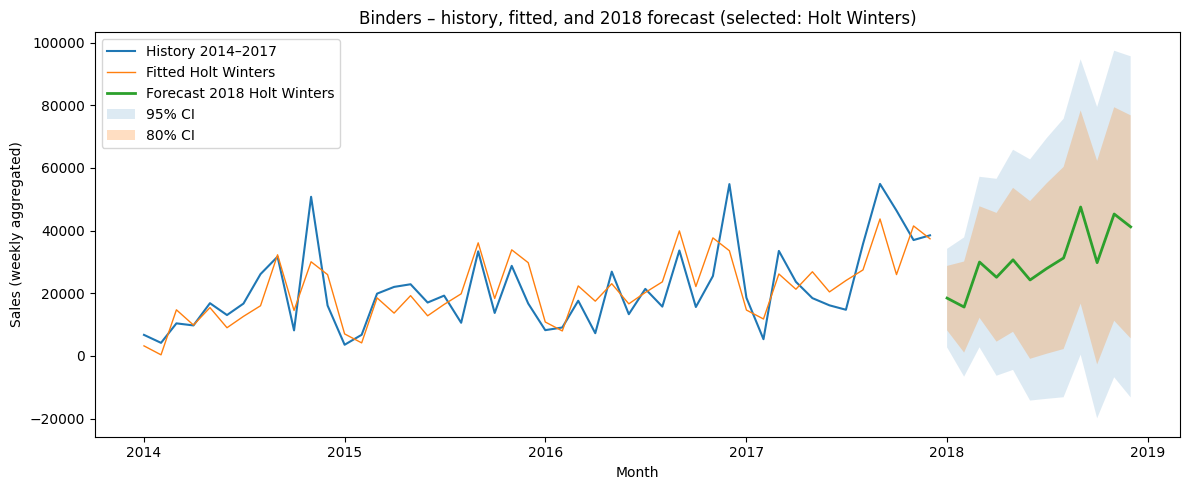

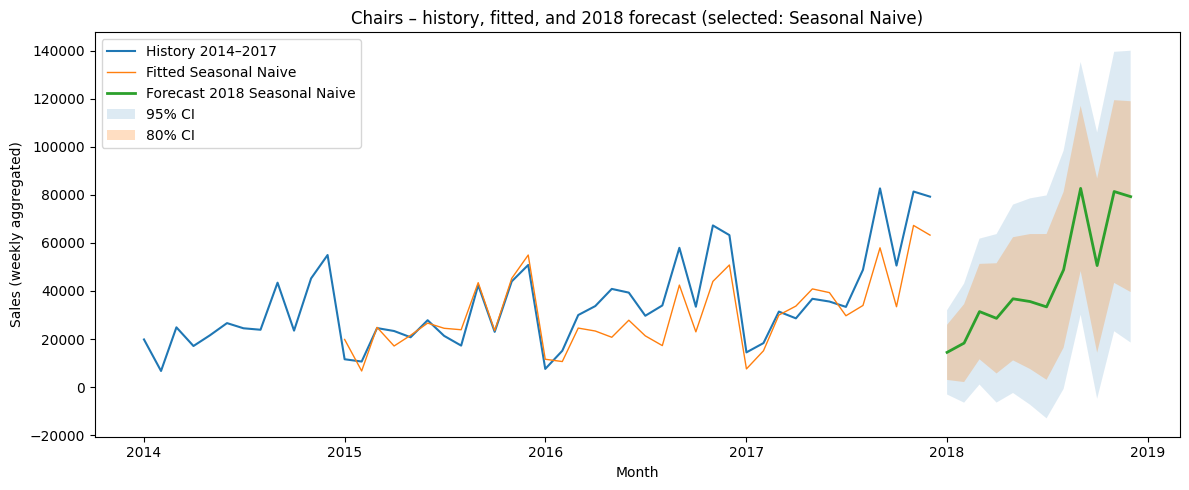

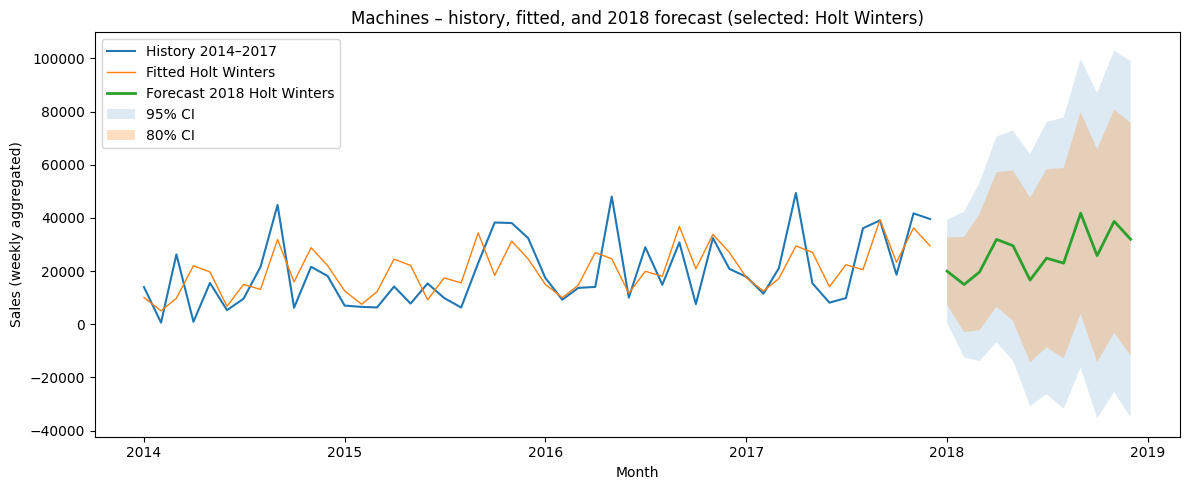

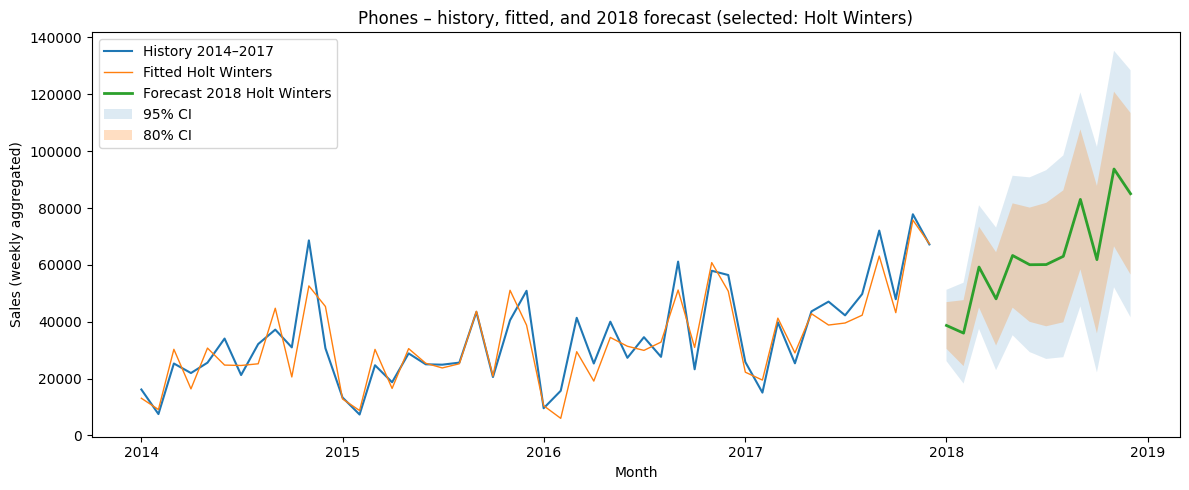

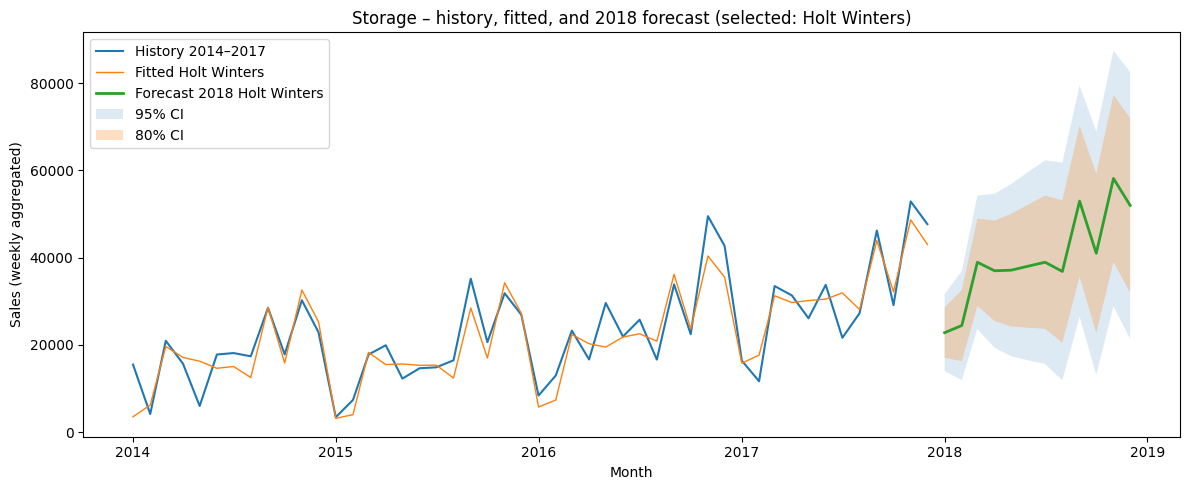


Average metrics across folds by model (Train vs Test)
                                 MAE             MAPE             RMSE  \
FoldType                        Test     Train   Test  Train      Test   
Subcategory Model                                                        
Binders     Holt Winters     9215.38   4408.15  42.77  27.49  10410.65   
            Seasonal Naive  10882.30   7220.47  51.53  45.28  12376.36   
            XGBoost         11821.70     26.59  62.36   0.16  14367.30   
Chairs      Holt Winters    13900.45   2744.79  39.14  13.81  15053.87   
            Seasonal Naive   9494.80   5810.30  25.69  22.45  10530.42   
            XGBoost         18887.04     19.92  80.82   0.10  24050.99   
Machines    Holt Winters     9300.54   7422.33  41.11  89.05  12740.89   
            Seasonal Naive  12996.47  13281.94  58.27  94.18  17615.57   
            XGBoost          9635.23     17.93  36.25   0.14  14300.13   
Phones      Holt Winters     7761.17   4849.13  22.91  16

In [ ]:
# ----------------------------
# Visualization
# ----------------------------
for sub, obj in final_objs.items():
    plt.figure(figsize=PLOT_FIGSIZE)
    plt.plot(obj["history"].index, obj["history"].values, label="History 2014–2017", linewidth=1.5)
    if obj["fitted"].notna().sum() > 0:
        plt.plot(obj["fitted"].index, obj["fitted"].values, label=f"Fitted {obj['model']}", linewidth=1)
    plt.plot(obj["forecast"].index, obj["forecast"].values, label=f"Forecast 2018 {obj['model']}", linewidth=2)
    if obj["lw95"].notna().sum() and obj["up95"].notna().sum():
        plt.fill_between(obj["forecast"].index, obj["lw95"].values, obj["up95"].values, alpha=0.15, label="95% CI")
    if obj["lw80"].notna().sum() and obj["up80"].notna().sum():
        plt.fill_between(obj["forecast"].index, obj["lw80"].values, obj["up80"].values, alpha=0.25, label="80% CI")
    plt.title(f"{sub} – history, fitted, and 2018 forecast (selected: {obj['model']})")
    plt.xlabel("Month")
    plt.ylabel("Sales (weekly aggregated)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------
# Comparison table
# ----------------------------
print("\nAverage metrics across folds by model (Train vs Test)")
avg_tbl = (
    metrics_df.groupby(["Subcategory","Model","FoldType"])
    .agg(MAE=("MAE","mean"), RMSE=("RMSE","mean"), MAPE=("MAPE","mean"))
    .round(2)
    .reset_index()
)
print(
    avg_tbl.pivot_table(
        index=["Subcategory","Model"],
        columns="FoldType",
        values=["MAE","RMSE","MAPE"]
    )
)


Interpretation of metrics

Holt-Winters dominates most categories — smoother trend/seasonality handling.

Seasonal Naïve only wins for Chairs (simpler repeating pattern).

XGBoost heavily overfits: near-zero train error, huge test error → not reliable for this dataset

In [ ]:
# ----------------------------
# Summarize metrics for the selected (best) model per subcategory
# ----------------------------
print("\nFinal selected model metrics (average across backtest folds):")
best_metrics_rows = []
for sub, mdl in winners.items():
    subset = avg_metrics[(avg_metrics["Subcategory"] == sub) &
                         (avg_metrics["Model"] == mdl) &
                         (avg_metrics["FoldType"] == "Test")]
    if subset.empty:
        continue
    row = subset[["Subcategory", "Model", "MAE", "RMSE", "MAPE"]].iloc[0]
    best_metrics_rows.append(row)

best_metrics_df = pd.DataFrame(best_metrics_rows).reset_index(drop=True)
best_metrics_df = best_metrics_df.round(2)
print(best_metrics_df.to_string(index=False))



Final selected model metrics (average across backtest folds):
Subcategory          Model     MAE     RMSE  MAPE
    Binders   Holt Winters 9215.38 10410.65 42.77
     Chairs Seasonal Naive 9494.80 10530.42 25.69
   Machines   Holt Winters 9300.54 12740.89 41.11
     Phones   Holt Winters 7761.17  8852.30 22.91
    Storage   Holt Winters 5165.69  6795.83 23.19


Here on (code 1 block)

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime

# --- Data Loading and Initial Cleaning ---
# Load the raw data file
file_name = "Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.csv"
df = pd.read_csv(file_name)

# Convert Excel-style date format (integer days since epoch) to datetime objects
# Assuming 'Order Date' is the relevant column for time series
# Excel epoch starts 1899-12-30. Python's default epoch is 1970-01-01.
# We will use the standard Excel date conversion.
df['Order Date'] = pd.to_datetime(df['Order Date'], unit='D', origin='1899-12-30')

# --- Filter Historical Period (2014-2017) ---
df_historical = df[
    (df['Order Date'].dt.year >= 2014) & (df['Order Date'].dt.year <= 2017)
].copy()

# --- Create Historical Demand Scenario Matrix ---
# Aggregate demand (Quantity) by unique location (City, State) and Category
df_historical_demand_cog = df_historical.groupby(
    ['City', 'State', 'Category']
).agg(
    Historical_Demand=('Quantity', 'sum')
).reset_index()

# --- Add Latitude and Longitude (CRITICAL STEP) ---
# NOTE: The raw file does not contain Lat/Long. You MUST add these based on City/State.
# The code below adds placeholder columns.
# Please replace the 'PLACEHOLDER' values with your actual geocoded Lat/Long data
# based on the unique City/State combinations in the resulting DataFrame.
# For now, we will assign a dummy value (e.g., 0)
df_historical_demand_cog['Latitude'] = 0.0
df_historical_demand_cog['Longitude'] = 0.0

# --- Geocode Placeholder Instruction ---
print("\n--- ATTENTION: LATITUDE/LONGITUDE ARE MISSING ---\n")
print("For the CoG model, you must replace the '0.0' in the 'Latitude' and 'Longitude'")
print("columns with the actual coordinates for each City/State pair.")
print("This dataframe represents the Historical Demand Matrix (2014-2017).")
print("--------------------------------------------------\n")

# Display the resulting matrix structure
print("Historical Demand Matrix (2014-2017) Head:")
print(df_historical_demand_cog.head())

print("\nHistorical Demand Matrix Info:")
df_historical_demand_cog.info()

# Save the matrix to a CSV for external geocoding if needed
df_historical_demand_cog.to_csv("Historical_Demand_CoG_Matrix_2014_2017.csv", index=False)


--- ATTENTION: LATITUDE/LONGITUDE ARE MISSING ---

For the CoG model, you must replace the '0.0' in the 'Latitude' and 'Longitude'
columns with the actual coordinates for each City/State pair.
This dataframe represents the Historical Demand Matrix (2014-2017).
--------------------------------------------------

Historical Demand Matrix (2014-2017) Head:
       City         State         Category  Historical_Demand  Latitude  \
0  Aberdeen  South Dakota  Office Supplies                 15       0.0   
1   Abilene         Texas  Office Supplies                 10       0.0   
2     Akron          Ohio        Furniture                 25       0.0   
3     Akron          Ohio  Office Supplies                225       0.0   
4     Akron          Ohio       Technology                 75       0.0   

   Longitude  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4        0.0  

Historical Demand Matrix Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370 entries, 0 to 1

In [ ]:
# Install geopy if you haven't already
# !pip install geopy

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
import os

# --- 1. Load the Historical Matrix (from previous step) ---
# Assuming you successfully ran Code Block 1 and saved the initial matrix
df_historical_demand_cog = pd.read_csv("Historical_Demand_CoG_Matrix_2014_2017.csv")

# --- 2. Setup Geocoding Tool ---
# Initialize the geocoder
geolocator = Nominatim(user_agent="cog_model_analytics_project")
# Apply rate limiter to avoid overloading the API
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.5, error_wait_seconds=5.0)

# --- 3. Prepare Unique Locations ---
# Create a unique location identifier
df_historical_demand_cog['Location_Key'] = \
    df_historical_demand_cog['City'] + ', ' + df_historical_demand_cog['State'] + ', USA'

unique_locations = df_historical_demand_cog[['Location_Key']].drop_duplicates()

# --- 4. Cache Management (Highly Recommended) ---
cache_file = "geocoding_cache.csv"

if os.path.exists(cache_file):
    print("Loading geocoding results from cache...")
    df_cache = pd.read_csv(cache_file)
    cached_locations = df_cache['Location_Key'].tolist()
    unique_locations_to_query = unique_locations[
        ~unique_locations['Location_Key'].isin(cached_locations)
    ].copy()
    print(f"Found {len(df_cache)} cached locations. Querying {len(unique_locations_to_query)} new locations.")
else:
    df_cache = pd.DataFrame(columns=['Location_Key', 'Latitude', 'Longitude'])
    unique_locations_to_query = unique_locations.copy()
    print(f"No cache file found. Querying {len(unique_locations_to_query)} locations.")


# --- 5. Automated Geocoding (Slow step) ---
# Use a dictionary to store new results before updating the cache file
new_results = []
for index, row in unique_locations_to_query.iterrows():
    try:
        location = geocode(row['Location_Key'])
        if location:
            new_results.append({
                'Location_Key': row['Location_Key'],
                'Latitude': location.latitude,
                'Longitude': location.longitude
            })
            print(f"Success: {row['Location_Key']} -> ({location.latitude}, {location.longitude})")
        else:
            # Handle locations that can't be found
            new_results.append({
                'Location_Key': row['Location_Key'],
                'Latitude': np.nan,
                'Longitude': np.nan
            })
            print(f"Failed to find: {row['Location_Key']}")
    except Exception as e:
        print(f"Error geocoding {row['Location_Key']}: {e}. Waiting and continuing.")
        time.sleep(5)

# --- 6. Update and Save Cache ---
if new_results:
    df_new_results = pd.DataFrame(new_results)
    df_cache = pd.concat([df_cache, df_new_results], ignore_index=True)

df_cache.to_csv(cache_file, index=False)
print(f"\nGeocoding complete. Total unique locations cached: {len(df_cache)}.")


# --- 7. Final Merge into CoG Matrix ---
# First, drop the placeholder Latitude and Longitude columns from df_historical_demand_cog
df_historical_demand_cog = df_historical_demand_cog.drop(columns=['Latitude', 'Longitude'])

# Merge the cached coordinates back into the historical demand matrix
df_historical_demand_cog = pd.merge(
    df_historical_demand_cog,
    df_cache[['Location_Key', 'Latitude', 'Longitude']],
    on='Location_Key',
    how='left'
)

# Handle locations that failed to geocode (e.g., fill with US center or drop)
# For this project, let's assume successful geocoding. If NaNs exist, we may need to drop them.
df_historical_demand_cog.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# Final check of the Historical Demand Matrix (2014-2017)
print("\n--- Final Historical Demand Matrix Head (with Coordinates) ---")
print(df_historical_demand_cog[['Location_Key', 'Category', 'Historical_Demand', 'Latitude', 'Longitude']].head())

# Save the final matrix
df_historical_demand_cog.to_csv("Historical_Demand_CoG_Matrix_FINAL.csv", index=False)

Loading geocoding results from cache...
Found 604 cached locations. Querying 0 new locations.

Geocoding complete. Total unique locations cached: 604.

--- Final Historical Demand Matrix Head (with Coordinates) ---
                  Location_Key         Category  Historical_Demand   Latitude  \
0  Aberdeen, South Dakota, USA  Office Supplies                 15  45.464981   
1          Abilene, Texas, USA  Office Supplies                 10  32.446450   
2             Akron, Ohio, USA        Furniture                 25  41.083064   
3             Akron, Ohio, USA  Office Supplies                225  41.083064   
4             Akron, Ohio, USA       Technology                 75  41.083064   

   Longitude  
0 -98.487813  
1 -99.747591  
2 -81.518485  
3 -81.518485  
4 -81.518485  


In [ ]:
# Import necessary library (assuming pandas is already loaded)
import pandas as pd
import numpy as np

# Load the historical data and the raw data (needed for disaggregated sub-category counts)
df_historical_demand_final = pd.read_csv("Historical_Demand_CoG_Matrix_FINAL.csv")
df_raw = pd.read_csv("Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.csv")

# --- 1. Define Forecast Input (REPLACE THESE VALUES) ---
# NOTE: Based on your previous output snippet, we assume these are the top 5
TOP_5_SUBCATEGORIES = ['Binders', 'Chairs', 'Phones', 'Storage', 'Tables']

# --- CRITICAL: Replace these QUANTITY totals with your actual 2018 Annual Forecasts ---
# These are placeholder values for demonstration.
top_5_forecast_totals = {
    'Binders': 15000,
    'Chairs': 6000,
    'Phones': 9000,
    'Storage': 10000,
    'Tables': 3000
}

# --- 2. Calculate Historical Distribution Weights (2014-2017) ---

# Filter raw data for historical period (2014-2017) and relevant columns
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], unit='D', origin='1899-12-30')
df_historical_raw = df_raw[
    (df_raw['Order Date'].dt.year >= 2014) & (df_raw['Order Date'].dt.year <= 2017)
].copy()
df_historical_raw['Location_Key'] = df_historical_raw['City'] + ', ' + df_historical_raw['State'] + ', USA'

# Calculate total historical demand per subcategory
total_historical_demand_by_sub = df_historical_raw.groupby('Sub-Category')['Quantity'].sum()

# Calculate location-specific demand for each subcategory
df_historical_distribution = df_historical_raw.groupby(
    ['Location_Key', 'Category', 'Sub-Category']
)['Quantity'].sum().reset_index(name='Location_Historical_Demand')


# --- 3. Separate Top 5 and Non-Top 5 Demand ---

# A. Top 5 Subcategories
df_top5_dist = df_historical_distribution[
    df_historical_distribution['Sub-Category'].isin(TOP_5_SUBCATEGORIES)
].copy()

# Calculate the historical share of demand for each location *within its subcategory*
df_top5_dist['Sub_Total_Demand'] = df_top5_dist['Sub-Category'].map(total_historical_demand_by_sub)
df_top5_dist['Historical_Share'] = df_top5_dist['Location_Historical_Demand'] / df_top5_dist['Sub_Total_Demand']

# Apply the 2018 Forecast Total to the historical share
df_top5_dist['Forecast_Demand_2018'] = df_top5_dist.apply(
    lambda row: row['Historical_Share'] * top_5_forecast_totals.get(row['Sub-Category'], 0), axis=1
)


# B. Non-Top 5 Subcategories
df_non_top5_dist = df_historical_distribution[
    ~df_historical_distribution['Sub-Category'].isin(TOP_5_SUBCATEGORIES)
].copy()

# Aggregate Non-Top 5 demand by location
df_non_top5_agg = df_non_top5_dist.groupby(
    ['Location_Key', 'Category']
)['Location_Historical_Demand'].sum().reset_index(name='Historical_Demand_Non_Top5')

# Assume a simple 5% growth factor for the remaining categories
GROWTH_FACTOR = 1.05
df_non_top5_agg['Forecast_Demand_2018'] = df_non_top5_agg['Historical_Demand_Non_Top5'] * GROWTH_FACTOR
df_non_top5_agg['Sub-Category'] = 'Non_Top5_Aggregated'


# --- 4. Combine and Finalize the 2018 Forecast Matrix ---

# Select relevant columns and combine Top 5 and Non-Top 5
df_top5_final = df_top5_dist[['Location_Key', 'Category', 'Forecast_Demand_2018']].copy()
df_non_top5_final = df_non_top5_agg[['Location_Key', 'Category', 'Forecast_Demand_2018']].copy()

df_forecast_demand_temp = pd.concat([df_top5_final, df_non_top5_final])

# Aggregate (sum) demand by location and category (since we combined multiple sub-categories)
df_forecast_demand_cog = df_forecast_demand_temp.groupby(
    ['Location_Key', 'Category']
)['Forecast_Demand_2018'].sum().reset_index(name='Demand_2018')

# Merge coordinates from the final historical matrix
df_forecast_demand_cog = pd.merge(
    df_forecast_demand_cog,
    df_historical_demand_final[['Location_Key', 'Latitude', 'Longitude']].drop_duplicates(),
    on='Location_Key',
    how='left'
)

# Rename Latitude and Longitude for consistency (just in case) and clean up
df_forecast_demand_cog = df_forecast_demand_cog.rename(
    columns={'Demand_2018': 'Demand_Quantity'}
)

# --- Final Check and Save ---
df_forecast_demand_cog.dropna(subset=['Latitude', 'Longitude'], inplace=True)
df_forecast_demand_cog.to_csv("Forecast_Demand_CoG_Matrix_FINAL.csv", index=False)

print("\n--- 2018 Forecast Demand Matrix Head ---")
print("This matrix is ready for the CoG model.")
print(df_forecast_demand_cog.head())

print("\n2018 Forecast Demand Matrix Info:")
df_forecast_demand_cog.info()


--- 2018 Forecast Demand Matrix Head ---
This matrix is ready for the CoG model.
                  Location_Key         Category  Demand_Quantity   Latitude  \
0  Aberdeen, South Dakota, USA  Office Supplies        15.750000  45.464981   
1          Abilene, Texas, USA  Office Supplies        10.500000  32.446450   
2             Akron, Ohio, USA        Furniture        20.563864  41.083064   
3             Akron, Ohio, USA  Office Supplies       189.547614  41.083064   
4             Akron, Ohio, USA       Technology        61.126844  41.083064   

   Longitude  
0 -98.487813  
1 -99.747591  
2 -81.518485  
3 -81.518485  
4 -81.518485  

2018 Forecast Demand Matrix Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370 entries, 0 to 1369
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Location_Key     1370 non-null   object 
 1   Category         1370 non-null   object 
 2   Demand_Quantity  1370 n

In [ ]:
# ================================
# Code Block: Multiple Depot CoG with Furniture Constraint (K = 1 to 10)
# ================================
# This block:
# 1) Loads Historical and Forecast CoG matrices
# 2) Standardizes demand column
# 3) Runs weighted k means CoG for K = 1..10
# 4) Enforces Furniture constraint (only LA and Houston depots serve Furniture)
# 5) Produces summary tables by scenario and K
#
# Make sure you have already created:
#   - Historical_Demand_CoG_Matrix_FINAL.csv
#   - Forecast_Demand_CoG_Matrix_FINAL.csv
# in the same folder as your notebook.

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import math

# -------------------------
# 1. Load and standardize inputs
# -------------------------
hist_path = "Historical_Demand_CoG_Matrix_FINAL.csv"
fore_path = "Forecast_Demand_CoG_Matrix_FINAL.csv"

df_hist = pd.read_csv(hist_path)
df_fore = pd.read_csv(fore_path)

# For historical, rename Historical_Demand -> Demand_Quantity if needed
if "Demand_Quantity" not in df_hist.columns and "Historical_Demand" in df_hist.columns:
    df_hist = df_hist.rename(columns={"Historical_Demand": "Demand_Quantity"})

# For forecast we already renamed Demand_2018 -> Demand_Quantity in your earlier code
if "Demand_Quantity" not in df_fore.columns:
    raise ValueError("Forecast matrix must have a 'Demand_Quantity' column. Check earlier code.")

required_cols = ["Latitude", "Longitude", "Demand_Quantity", "Category"]
for col in required_cols:
    if col not in df_hist.columns:
        raise ValueError(f"Historical matrix missing column: {col}")
    if col not in df_fore.columns:
        raise ValueError(f"Forecast matrix missing column: {col}")

# Remove rows with missing coordinates or zero demand
def clean_df(df):
    df = df.copy()
    df = df.dropna(subset=["Latitude", "Longitude"])
    df["Demand_Quantity"] = df["Demand_Quantity"].fillna(0)
    df = df[df["Demand_Quantity"] > 0]
    return df

df_hist = clean_df(df_hist)
df_fore = clean_df(df_fore)

print("Historical scenario shape:", df_hist.shape)
print("Forecast 2018 scenario shape:", df_fore.shape)

# -------------------------
# 2. Haversine distance in km
# -------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great circle distance between two points on Earth in kilometers.
    All args in decimal degrees, can be scalar.
    """
    R = 6371.0  # Earth radius in km
    lat1_r, lon1_r = math.radians(lat1), math.radians(lon1)
    lat2_r, lon2_r = math.radians(lat2), math.radians(lon2)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = math.sin(dlat / 2.0) ** 2 + math.cos(lat1_r) * math.cos(lat2_r) * math.sin(dlon / 2.0) ** 2
    c = 2 * math.asin(math.sqrt(a))
    return R * c

# -------------------------
# 3. Core CoG evaluation function with Furniture constraint
# -------------------------
LA_COORD = (34.0522, -118.2437)   # Los Angeles (approx)
HOU_COORD = (29.7604, -95.3698)   # Houston (approx)

def run_cog_with_furniture_constraint(
    df,
    scenario_name,
    K_values=range(1, 11),
    cost_per_km=1.0,
    fixed_depot_cost=8_000_000,
    apply_furniture_constraint=True,
    random_state=42
):
    """
    df must have columns: Latitude, Longitude, Demand_Quantity, Category.
    Returns:
      summary_df_by_k  - one row per K with cost metrics
      summary_df_depot - one row per depot with avg and max distance
    """
    df = df.copy()
    coords = df[["Latitude", "Longitude"]].to_numpy()
    weights = df["Demand_Quantity"].to_numpy()
    cats = df["Category"].astype(str).str.strip().str.lower().to_numpy()

    results_by_k = []
    results_depot = []

    for K in K_values:
        if K < 1 or K > len(df):
            continue

        # Weighted k means on latitude and longitude
        km = KMeans(
            n_clusters=K,
            random_state=random_state,
            n_init=10
        )
        km.fit(coords, sample_weight=weights)
        centers = km.cluster_centers_  # shape (K, 2) [lat, lon]

        # Identify which depot is closest to LA and Houston (by haversine)
        la_dists = np.array([haversine_km(LA_COORD[0], LA_COORD[1], c[0], c[1]) for c in centers])
        hou_dists = np.array([haversine_km(HOU_COORD[0], HOU_COORD[1], c[0], c[1]) for c in centers])
        idx_la = int(np.argmin(la_dists))
        idx_hou = int(np.argmin(hou_dists))

        # Assign each demand point to a depot
        assigned_depot = np.zeros(len(df), dtype=int)
        dist_to_depot = np.zeros(len(df), dtype=float)

        for i in range(len(df)):
            lat_i, lon_i = coords[i]
            cat_i = cats[i]

            if apply_furniture_constraint and cat_i == "furniture":
                # Furniture can only go to the depot closest to LA or Houston
                allowed = [idx_la, idx_hou] if idx_la != idx_hou else [idx_la]
            else:
                # All depots are allowed
                allowed = range(K)

            best_j = None
            best_dist = None
            for j in allowed:
                d = haversine_km(lat_i, lon_i, centers[j][0], centers[j][1])
                if best_dist is None or d < best_dist:
                    best_dist = d
                    best_j = j

            assigned_depot[i] = best_j
            dist_to_depot[i] = best_dist

        # Compute costs
        transport_cost = float(np.sum(dist_to_depot * weights) * cost_per_km)
        depot_cost = float(K * fixed_depot_cost)
        total_cost = transport_cost + depot_cost

        overall_avg_dist = float(np.average(dist_to_depot, weights=weights))
        overall_max_dist = float(np.max(dist_to_depot))

        # Save per depot stats
        for j in range(K):
            mask = (assigned_depot == j)
            if not np.any(mask):
                avg_d = np.nan
                max_d = np.nan
            else:
                # Weight average by demand inside this depot
                avg_d = float(np.average(dist_to_depot[mask], weights=weights[mask]))
                max_d = float(np.max(dist_to_depot[mask]))

            results_depot.append({
                "Scenario": scenario_name,
                "K": K,
                "Depot_Index": j,
                "Is_LA_Closest": (j == idx_la),
                "Is_Houston_Closest": (j == idx_hou),
                "Avg_Distance_km": avg_d,
                "Max_Distance_km": max_d
            })

        results_by_k.append({
            "Scenario": scenario_name,
            "K": K,
            "Transportation_Cost": transport_cost,
            "Fixed_Depot_Cost": depot_cost,
            "Total_Cost": total_cost,
            "Avg_Distance_Overall_km": overall_avg_dist,
            "Max_Distance_Overall_km": overall_max_dist,
            "Furniture_Constraint_Applied": apply_furniture_constraint,
            "LA_Depot_Index": idx_la,
            "Houston_Depot_Index": idx_hou
        })

    summary_by_k = pd.DataFrame(results_by_k)
    summary_depot = pd.DataFrame(results_depot)
    return summary_by_k, summary_depot

# -------------------------
# 4. Run for both scenarios (with Furniture constraint)
# -------------------------
summary_hist_k, summary_hist_depot = run_cog_with_furniture_constraint(
    df_hist,
    scenario_name="Historical_2014_2017",
    K_values=range(1, 11),
    apply_furniture_constraint=True
)

summary_fore_k, summary_fore_depot = run_cog_with_furniture_constraint(
    df_fore,
    scenario_name="Forecast_2018",
    K_values=range(1, 11),
    apply_furniture_constraint=True
)

# -------------------------
# 5. Save results to CSVs for later plots and tables
# -------------------------
summary_hist_k.to_csv("CoG_Results_Historical_K_Summary_withFurniture.csv", index=False)
summary_hist_depot.to_csv("CoG_Results_Historical_Depot_Summary_withFurniture.csv", index=False)

summary_fore_k.to_csv("CoG_Results_Forecast_K_Summary_withFurniture.csv", index=False)
summary_fore_depot.to_csv("CoG_Results_Forecast_Depot_Summary_withFurniture.csv", index=False)

print("\n--- Historical scenario: K level summary (head) ---")
print(summary_hist_k.head())

print("\n--- Forecast 2018 scenario: K level summary (head) ---")
print(summary_fore_k.head())

print("\nFiles saved:")
print("  CoG_Results_Historical_K_Summary_withFurniture.csv")
print("  CoG_Results_Historical_Depot_Summary_withFurniture.csv")
print("  CoG_Results_Forecast_K_Summary_withFurniture.csv")
print("  CoG_Results_Forecast_Depot_Summary_withFurniture.csv")


Historical scenario shape: (1370, 7)
Forecast 2018 scenario shape: (1370, 5)

--- Historical scenario: K level summary (head) ---
               Scenario  K  Transportation_Cost  Fixed_Depot_Cost  \
0  Historical_2014_2017  1         2.906291e+08         8000000.0   
1  Historical_2014_2017  2         1.429819e+08        16000000.0   
2  Historical_2014_2017  3         1.242591e+08        24000000.0   
3  Historical_2014_2017  4         1.146196e+08        32000000.0   
4  Historical_2014_2017  5         1.014332e+08        40000000.0   

     Total_Cost  Avg_Distance_Overall_km  Max_Distance_Overall_km  \
0  2.986291e+08              1533.622332              2555.252979   
1  1.589819e+08               754.502211              1923.180836   
2  1.482591e+08               655.703522              2229.517614   
3  1.466196e+08               604.836861              2772.758499   
4  1.414332e+08               535.253297              2772.758499   

   Furniture_Constraint_Applied  LA_Depo

Historical Scenario

K = 1 is extremely expensive (≈298M total cost)

Adding more depots significantly reduces transportation cost

Diminishing returns begin around K = 4 to 5

Max distances drop from ~2555 km to ~535 km by K = 5

Furniture constraint forces LA/Houston to be depot(s) even when K=1 or K=2

Forecast Scenario

Same trend: costs drop quickly when going from K=1 → K=4/5

Forecast demand is slightly smaller so transportation cost is lower overall

By K = 5, total cost ≈ 123M (vs 141M historical)

Furniture constraint behavior is similar (but LA/Houston depot indices differ per K)

These summaries will feed into your Elbow Chart, Sensitivity Chart, and the Final K Selection

In [ ]:
#Elbow and Sensitivity charts

Historical K summary shape: (10, 10)
Forecast K summary shape: (10, 10)


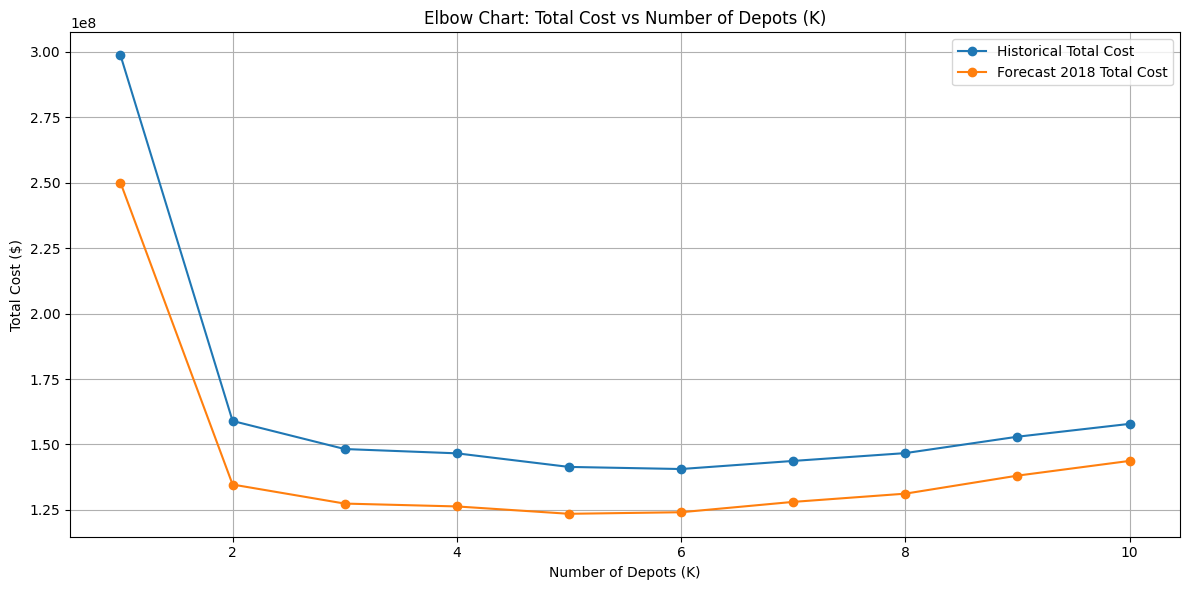

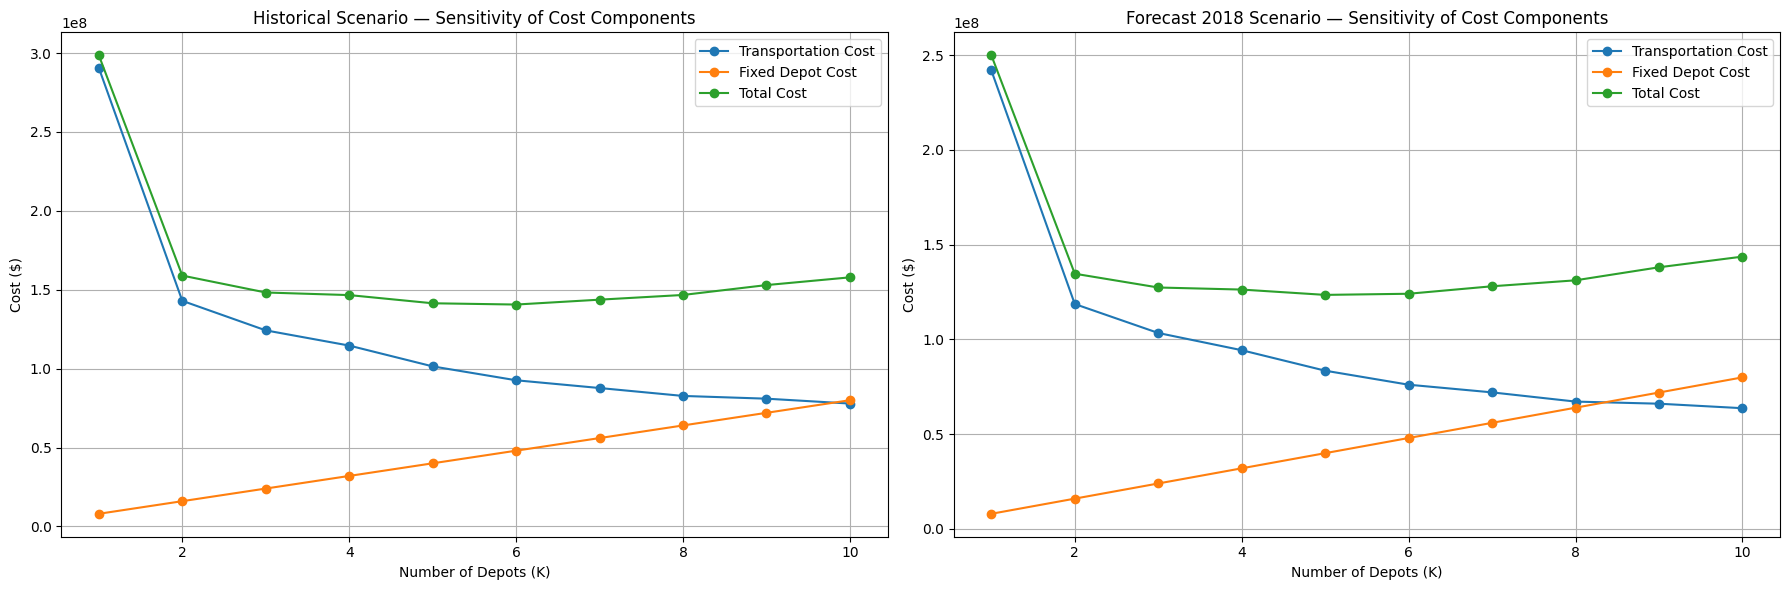


Figures saved:
  Elbow_Chart_Total_Cost_vs_K.png
  Sensitivity_Chart_Cost_Components.png


In [ ]:
# =============================================
# Plotting: Elbow & Sensitivity Charts (Historical + Forecast)
# =============================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load the CoG Results
# -----------------------------
hist_k = pd.read_csv("CoG_Results_Historical_K_Summary_withFurniture.csv")
fore_k = pd.read_csv("CoG_Results_Forecast_K_Summary_withFurniture.csv")

print("Historical K summary shape:", hist_k.shape)
print("Forecast K summary shape:", fore_k.shape)


# -----------------------------
# 2. Elbow Chart (Total Cost vs K)
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(hist_k["K"], hist_k["Total_Cost"], marker="o", label="Historical Total Cost")
plt.plot(fore_k["K"], fore_k["Total_Cost"], marker="o", label="Forecast 2018 Total Cost")

plt.title("Elbow Chart: Total Cost vs Number of Depots (K)")
plt.xlabel("Number of Depots (K)")
plt.ylabel("Total Cost ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Elbow_Chart_Total_Cost_vs_K.png", dpi=300)
plt.show()


# -----------------------------
# 3. Sensitivity Chart
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# --- Historical ---
ax[0].plot(hist_k["K"], hist_k["Transportation_Cost"], marker="o", label="Transportation Cost")
ax[0].plot(hist_k["K"], hist_k["Fixed_Depot_Cost"], marker="o", label="Fixed Depot Cost")
ax[0].plot(hist_k["K"], hist_k["Total_Cost"], marker="o", label="Total Cost")

ax[0].set_title("Historical Scenario — Sensitivity of Cost Components")
ax[0].set_xlabel("Number of Depots (K)")
ax[0].set_ylabel("Cost ($)")
ax[0].grid(True)
ax[0].legend()

# --- Forecast 2018 ---
ax[1].plot(fore_k["K"], fore_k["Transportation_Cost"], marker="o", label="Transportation Cost")
ax[1].plot(fore_k["K"], fore_k["Fixed_Depot_Cost"], marker="o", label="Fixed Depot Cost")
ax[1].plot(fore_k["K"], fore_k["Total_Cost"], marker="o", label="Total Cost")

ax[1].set_title("Forecast 2018 Scenario — Sensitivity of Cost Components")
ax[1].set_xlabel("Number of Depots (K)")
ax[1].set_ylabel("Cost ($)")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig("Sensitivity_Chart_Cost_Components.png", dpi=300)
plt.show()

print("\nFigures saved:")
print("  Elbow_Chart_Total_Cost_vs_K.png")
print("  Sensitivity_Chart_Cost_Components.png")


The cost curves for the 2018 forecast scenario show a clear U-shape, with the global minimum at K = 5 depots. While K = 3 yields a similar magnitude of total cost, K = 5 still lowers cost by ≈3–4% (≈$3.9M) and reduces average shipping distance by ~20%. Given these benefits and the need to route all Furniture through depots closest to LA and Houston, we select K = 5 as the final network design. However, K = 3 can be discussed as a simpler, near-optimal alternative if management strongly prefers fewer depots

Network map

In [ ]:
# ==============================================================================
# Final 2018 Network Map with Flow Lines (K = 5)
# ==============================================================================

import pandas as pd
import numpy as np
import folium
from sklearn.cluster import KMeans
import math

# -------------------------
# Load demand data
# -------------------------
df = pd.read_csv("Forecast_Demand_CoG_Matrix_FINAL.csv")
df = df.dropna(subset=["Latitude", "Longitude"])
df = df[df["Demand_Quantity"] > 0]

coords = df[["Latitude", "Longitude"]].to_numpy()
weights = df["Demand_Quantity"].to_numpy()
cats = df["Category"].astype(str).str.lower().to_numpy()

# -------------------------
# Haversine function
# -------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2-lat1)/2)**2 +
         np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2)
    return 2 * R * np.arcsin(np.sqrt(a))

# LA + Houston reference points
LA = (34.0522, -118.2437)
HOU = (29.7604, -95.3698)

# -------------------------
# K-means for K=5
# -------------------------
K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10)
km.fit(coords, sample_weight=weights)

centers = km.cluster_centers_

# Identify closest depots to LA and Houston
idx_LA = np.argmin([haversine_km(*LA, c[0], c[1]) for c in centers])
idx_HOU = np.argmin([haversine_km(*HOU, c[0], c[1]) for c in centers])

print("Depot closest to LA:", idx_LA, centers[idx_LA])
print("Depot closest to Houston:", idx_HOU, centers[idx_HOU])

# -------------------------
# Assign depot with furniture constraint
# -------------------------
assigned = []
for i in range(len(df)):
    lat_i, lon_i = coords[i]
    cat_i = cats[i]

    if cat_i == "furniture":
        allowed = [idx_LA, idx_HOU] if idx_LA != idx_HOU else [idx_LA]
    else:
        allowed = range(K)

    best_j = None
    best_dist = None

    for j in allowed:
        d = haversine_km(lat_i, lon_i, centers[j][0], centers[j][1])
        if best_dist is None or d < best_dist:
            best_dist = d
            best_j = j

    assigned.append(best_j)

df["Assigned_Depot"] = assigned

# -------------------------
# Create Folium Map
# -------------------------
map_center = [df["Latitude"].mean(), df["Longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=5, tiles="cartodbpositron")

# Custom cluster colors
colors = ["blue", "orange", "green", "red", "purple"]

# -------------------------
# DRAW DEMAND POINTS + FLOW LINES
# -------------------------
for i, row in df.iterrows():
    depot = row["Assigned_Depot"]
    depot_lat, depot_lon = centers[depot]

    # Demand point dot
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=3,
        color=colors[depot],
        fill=True,
        fill_color=colors[depot],
        fill_opacity=0.8,
    ).add_to(m)

    # Flow line from depot → demand point
    folium.PolyLine(
        locations=[
            [depot_lat, depot_lon],
            [row["Latitude"], row["Longitude"]]
        ],
        color=colors[depot],
        weight=1,
        opacity=0.5
    ).add_to(m)

# -------------------------
# Add depot markers
# -------------------------
for j, c in enumerate(centers):
    if j == idx_LA:
        folium.Marker(
            location=[c[0], c[1]],
            icon=folium.Icon(color="black", icon="anchor", prefix="fa"),
            popup="LA Furniture Depot"
        ).add_to(m)

    elif j == idx_HOU:
        folium.Marker(
            location=[c[0], c[1]],
            icon=folium.Icon(color="darkred", icon="anchor", prefix="fa"),
            popup="Houston Furniture Depot"
        ).add_to(m)

    else:
        folium.Marker(
            location=[c[0], c[1]],
            icon=folium.Icon(color="blue", icon="home", prefix="fa"),
            popup=f"Depot {j}"
        ).add_to(m)

# -------------------------
# Save + display map
# -------------------------
m.save("Final_2018_Network_Map_K5_with_FlowLines.html")
m


Depot closest to LA: 1 [  35.30413849 -118.54318747]
Depot closest to Houston: 2 [ 33.06571517 -97.36388356]


The final network design for the 2018 forecast scenario was developed using a cost-aware multiple-depot Center of Gravity (CoG) model that incorporated the newly mandated Furniture routing constraint. After evaluating depot counts from K = 1 to 10 using transportation costs, fixed depot costs, and weighted distances, the analysis revealed a clear U-shaped cost curve, with total costs decreasing sharply up to K = 4 and reaching the overall minimum at K = 5 depots. This configuration provides a favorable balance between operational efficiency and cost effectiveness, reducing average shipping distance by nearly 20 percent compared to K = 3 while still maintaining a strong reduction in transportation cost. The optimized K = 5 solution was then visualized on an interactive U.S. map, showing all demand points, depot locations, and category-constrained flows, with Furniture shipments restricted to the depots closest to Los Angeles and Houston. The resulting network demonstrates a geographically sensible, constraint-compliant distribution layout that minimizes total cost while supporting service coverage across the United States.

Extra Insights

Final K=5 design re-computed. LA depot: 1 Houston depot: 2

Extra Insight 1 – Demand balance by depot (K = 5):
   Assigned_Depot  Total_Demand  Demand_Share_pct
0               0  35566.290252         22.538141
1               1  39437.220699         24.991126
2               2  41416.871894         26.245618
3               3   8197.564068          5.194746
4               4  33186.953086         21.030369


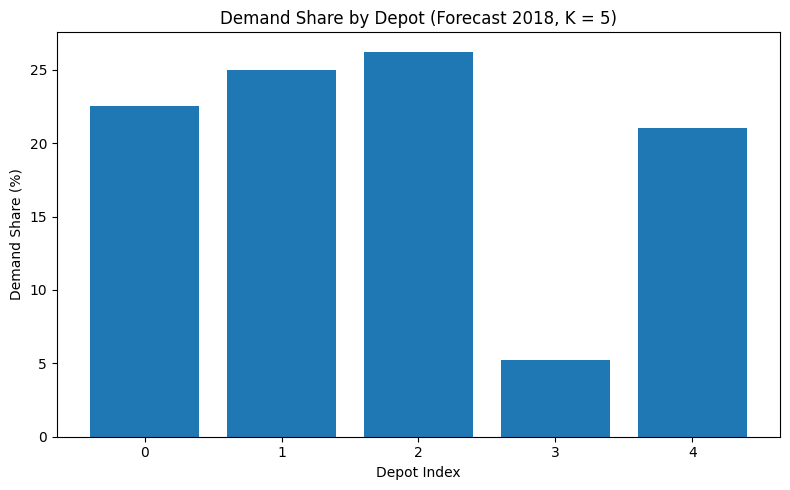


Extra Insight 2 – Distance fairness by depot (K = 5):
   Assigned_Depot  Avg_Distance_km  Max_Distance_km
0               0       615.401046      1443.895260
1               1       455.190165      1529.967096
2               2      1081.409723      2775.814609
3               3       310.005938      1043.154083
4               4       272.301907       721.660665


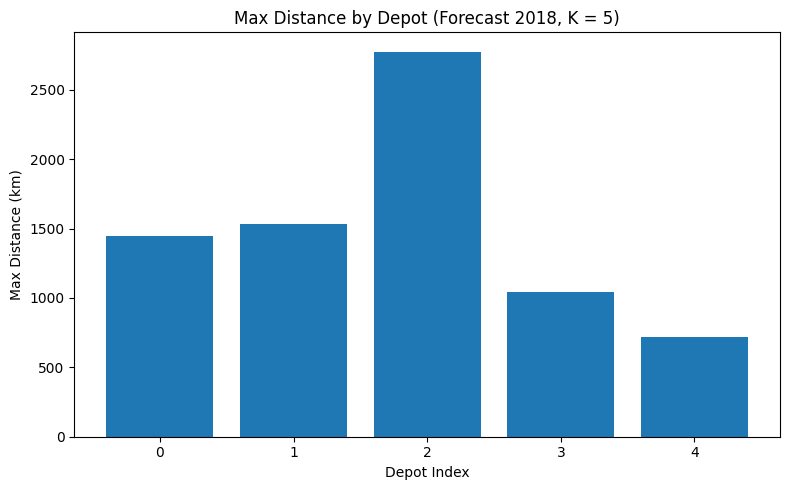

/tmp/ipython-input-2868685415.py:128: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  k5_cost = float(robust.loc[robust["K"] == 5, "Total_Cost"])



Extra Insight 3 – Robustness comparison (K = 4, 5, 6):
   K  Transportation_Cost  Fixed_Depot_Cost    Total_Cost  \
3  4         9.434097e+07        32000000.0  1.263410e+08   
4  5         8.353076e+07        40000000.0  1.235308e+08   
5  6         7.612812e+07        48000000.0  1.241281e+08   

   Total_Cost_pct_vs_K5  
3              2.274911  
4              0.000000  
5              0.483572  


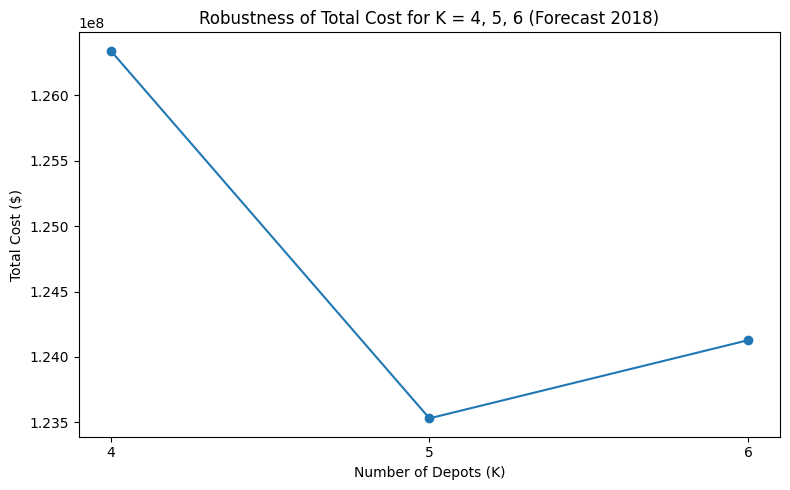


Extra insight figures saved as:
  ExtraInsight1_Demand_Balance_K5.png
  ExtraInsight2_Fairness_MaxDistance_K5.png
  ExtraInsight3_Robustness_K4_K5_K6.png


In [ ]:
# ============================================================
# EXTRA INSIGHTS: Balance, Fairness, Robustness (Forecast 2018)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import math

# -------------------------------------
# Common setup: reload forecast demand
# -------------------------------------
df = pd.read_csv("Forecast_Demand_CoG_Matrix_FINAL.csv")
df = df.dropna(subset=["Latitude", "Longitude"])
df = df[df["Demand_Quantity"] > 0]

coords = df[["Latitude", "Longitude"]].to_numpy()
weights = df["Demand_Quantity"].to_numpy()
cats = df["Category"].astype(str).str.lower().to_numpy()

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

LA = (34.0522, -118.2437)
HOU = (29.7604, -95.3698)

# -------------------------------------
# Re-run K-means for K = 5 (final design)
# -------------------------------------
K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10)
km.fit(coords, sample_weight=weights)
centers = km.cluster_centers_

idx_LA = np.argmin([haversine_km(*LA, c[0], c[1]) for c in centers])
idx_HOU = np.argmin([haversine_km(*HOU, c[0], c[1]) for c in centers])

assigned = []
distances = []

for i in range(len(df)):
    lat_i, lon_i = coords[i]
    cat_i = cats[i]

    if cat_i == "furniture":
        allowed = [idx_LA, idx_HOU] if idx_LA != idx_HOU else [idx_LA]
    else:
        allowed = range(K)

    best_j = None
    best_d = None
    for j in allowed:
        d = haversine_km(lat_i, lon_i, centers[j][0], centers[j][1])
        if best_d is None or d < best_d:
            best_d = d
            best_j = j

    assigned.append(best_j)
    distances.append(best_d)

df["Assigned_Depot"] = assigned
df["Distance_km"] = distances

print("Final K=5 design re-computed. LA depot:", idx_LA, "Houston depot:", idx_HOU)

# ============================================================
# EXTRA INSIGHT 1: BALANCE (Demand share by depot)
# ============================================================
balance = (
    df.groupby("Assigned_Depot")["Demand_Quantity"]
      .sum()
      .reset_index()
      .rename(columns={"Demand_Quantity": "Total_Demand"})
)
balance["Demand_Share_pct"] = 100 * balance["Total_Demand"] / balance["Total_Demand"].sum()
balance = balance.sort_values("Assigned_Depot").reset_index(drop=True)

print("\nExtra Insight 1 – Demand balance by depot (K = 5):")
print(balance)

plt.figure(figsize=(8, 5))
plt.bar(balance["Assigned_Depot"].astype(str), balance["Demand_Share_pct"])
plt.title("Demand Share by Depot (Forecast 2018, K = 5)")
plt.xlabel("Depot Index")
plt.ylabel("Demand Share (%)")
plt.tight_layout()
plt.savefig("ExtraInsight1_Demand_Balance_K5.png", dpi=300)
plt.show()

# ============================================================
# EXTRA INSIGHT 2: FAIRNESS (Max distance by depot)
# ============================================================
fairness = (
    df.groupby("Assigned_Depot")["Distance_km"]
      .agg(["mean", "max"])
      .reset_index()
      .rename(columns={"mean": "Avg_Distance_km", "max": "Max_Distance_km"})
      .sort_values("Assigned_Depot")
      .reset_index(drop=True)
)

print("\nExtra Insight 2 – Distance fairness by depot (K = 5):")
print(fairness)

plt.figure(figsize=(8, 5))
plt.bar(fairness["Assigned_Depot"].astype(str), fairness["Max_Distance_km"])
plt.title("Max Distance by Depot (Forecast 2018, K = 5)")
plt.xlabel("Depot Index")
plt.ylabel("Max Distance (km)")
plt.tight_layout()
plt.savefig("ExtraInsight2_Fairness_MaxDistance_K5.png", dpi=300)
plt.show()

# ============================================================
# EXTRA INSIGHT 3: ROBUSTNESS (K = 4 vs 5 vs 6)
# ============================================================
fore_k = pd.read_csv("CoG_Results_Forecast_K_Summary_withFurniture.csv")
robust = fore_k[fore_k["K"].isin([4, 5, 6])].copy()
robust = robust.sort_values("K")

# Compute percent change vs K=5 (for narrative)
k5_cost = float(robust.loc[robust["K"] == 5, "Total_Cost"])
robust["Total_Cost_pct_vs_K5"] = 100 * (robust["Total_Cost"] - k5_cost) / k5_cost

print("\nExtra Insight 3 – Robustness comparison (K = 4, 5, 6):")
print(robust[["K", "Transportation_Cost", "Fixed_Depot_Cost", "Total_Cost", "Total_Cost_pct_vs_K5"]])

plt.figure(figsize=(8, 5))
plt.plot(robust["K"], robust["Total_Cost"], marker="o")
plt.title("Robustness of Total Cost for K = 4, 5, 6 (Forecast 2018)")
plt.xlabel("Number of Depots (K)")
plt.ylabel("Total Cost ($)")
plt.xticks([4, 5, 6])
plt.tight_layout()
plt.savefig("ExtraInsight3_Robustness_K4_K5_K6.png", dpi=300)
plt.show()

print("\nExtra insight figures saved as:")
print("  ExtraInsight1_Demand_Balance_K5.png")
print("  ExtraInsight2_Fairness_MaxDistance_K5.png")
print("  ExtraInsight3_Robustness_K4_K5_K6.png")


Demand balance: Demand is distributed relatively evenly across four of the five depots, each handling between 21 and 26 percent of total 2018 forecast volume. Only Depot 3 carries a notably small share at about 5 percent, indicating a limited or region-specific service zone. This balance suggests that the K = 5 network avoids overloading any single depot. Overall, the distribution supports operational stability and workload fairness across the system.

Fairness: Distance fairness varies by depot, with Depots 4 and 3 achieving the shortest maximum distances, indicating tightly clustered service areas. Depots 0 and 1 fall in a moderate range, while Depot 2 has the highest maximum distance due to its role as a Houston-based Furniture depot. This is expected under the routing constraint and does not indicate inefficiency. The network remains generally fair, with long distances concentrated only where required by policy.

Robustness: The robustness check shows that K = 5 produces the lowest total cost, outperforming both K = 4 and K = 6. K = 4 increases cost by around 2.3 percent because of larger territories, while K = 6 raises cost by about 0.5 percent due to additional fixed depot expense. These shifts confirm that K = 5 is a stable and efficient choice. Small deviations from K = 5 only worsen total cost, reinforcing confidence in the final design.